# Phase 2 & 3 — Feature Engineering and Regression Modeling (Final)

**Dataset:** IPEDS 2022 — U.S. four-year institutions
**Input:** `ipeds2022_phase1_clean.csv` (output of the revised Phase 1 EDA notebook)

This notebook picks up where Phase 1 left off. Phase 1 completed all
data cleaning, predictor imputation, and preliminary feature creation.
**No Phase 1 work is repeated here.**

## Analysis Design

For each of the four target variables, we answer two questions:

1. **Which regression algorithm predicts the target best?**
2. **Does adding engineered features improve prediction?**

| Dimension | Options | Count |
|---|---|---|
| Targets | grad_rate_6yr, grad_rate_total, pell_grad_rate, retention_rate | 4 |
| Algorithms | Linear Regression, Ridge, Lasso, Random Forest, Gradient Boosting | 5 |
| Feature sets | Baseline (raw only), Engineered (raw + 3 engineered features) | 2 |
| **Total combinations** | 4 × 5 × 2 | **40** |

Every combination is evaluated using 5-fold cross-validation on the
training set. Cross-validation selects both the best algorithm **and**
whether the final model uses the baseline or engineered feature set.
Engineered features are **not** automatically included.

## Section 1 — Import Libraries

In [1]:
import warnings
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

TARGET_COLS = [
    "grad_rate_6yr",
    "grad_rate_total",
    "pell_grad_rate",
    "retention_rate",
]

ENGINEERED_FEATURES = [
    "affordability_index",
    "parttime_share",
    "loan_burden_ratio",
]

ID_COLS = ["unitid", "institution name", "year", "level"]

print("All libraries imported successfully.")

All libraries imported successfully.


---
## Section 2 — Load and Verify Phase 1 Data

Phase 1 completed all predictor imputation. No predictor column should
contain missing values. The four target variables intentionally retain
NaN for institutions that did not report those outcomes.

In [2]:
PHASE1_FILE = "ipeds2022_phase1_clean.csv"
df = pd.read_csv(PHASE1_FILE)
print(f"Loaded {PHASE1_FILE}: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded ipeds2022_phase1_clean.csv: 2,629 rows × 26 columns


In [3]:
# ── Integrity assertions ──────────────────────────────────────────────
required = [
    "unitid", "institution name", "year", "tuition",
    "retention_rate", "student_faculty_ratio", "pell_pct",
    "inst_grant_aid", "loan_pct", "avg_fed_loan",
    "grad_rate_total", "grad_rate_6yr", "pell_grad_rate",
    "size_cat", "state", "level", "control", "locale",
    "admit_rate", "total_enroll", "parttime_enroll",
    "instr_exp_per_fte", "locale_broad", "admit_rate_missing",
    "affordability_index", "parttime_share",
]
for c in required:
    assert c in df.columns, f"Missing: {c}"

assert df["unitid"].is_unique, "unitid not unique"
assert (df["level"] == "Four or more years").all(), "Non-four-year rows"

for t in TARGET_COLS:
    assert df[t].isna().sum() > 0, f"{t} fully populated — was it imputed?"

assert "admit_rate_missing" in df.columns
assert "affordability_index" in df.columns
assert "parttime_share" in df.columns

# CRITICAL — no predictor missingness
pred_cols = [c for c in df.columns if c not in TARGET_COLS]
pred_miss = df[pred_cols].isnull().sum()
pred_miss = pred_miss[pred_miss > 0]
assert len(pred_miss) == 0, f"Predictor NaN found:\n{pred_miss}"

print("All predictor columns: zero missing values.")
print("\nTarget missingness (intentional):")
for t in TARGET_COLS:
    print(f"  {t}: {df[t].notna().sum():,} observed, "
          f"{df[t].isna().sum():,} missing ({df[t].isna().mean()*100:.1f}%)")
print(f"\nAll integrity checks passed.")

All predictor columns: zero missing values.

Target missingness (intentional):
  grad_rate_6yr: 1,915 observed, 714 missing (27.2%)
  grad_rate_total: 2,168 observed, 461 missing (17.5%)
  pell_grad_rate: 1,822 observed, 807 missing (30.7%)
  retention_rate: 1,998 observed, 631 missing (24.0%)

All integrity checks passed.


In [4]:
print(f"Dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns\n")
print("Columns:")
for i, c in enumerate(df.columns, 1):
    print(f"  {i:2d}. {c}")

Dimensions: 2,629 rows × 26 columns

Columns:
   1. unitid
   2. institution name
   3. year
   4. tuition
   5. retention_rate
   6. student_faculty_ratio
   7. pell_pct
   8. inst_grant_aid
   9. loan_pct
  10. avg_fed_loan
  11. grad_rate_total
  12. grad_rate_6yr
  13. pell_grad_rate
  14. size_cat
  15. state
  16. level
  17. control
  18. locale
  19. admit_rate
  20. total_enroll
  21. parttime_enroll
  22. instr_exp_per_fte
  23. locale_broad
  24. admit_rate_missing
  25. affordability_index
  26. parttime_share


### Interpretation — Data Loading and Verification

The dataset contains **2,629 four-year U.S. institutions** from IPEDS 2022
across 26 columns. All predictor columns have **zero missing values**,
confirming that Phase 1 imputation was comprehensive.

Target-variable missingness ranges from roughly 17 % (`grad_rate_total`)
to 31 % (`pell_grad_rate`). This missingness is **expected and
intentional** — not every institution reports every outcome to IPEDS.
Institutions missing a particular target are excluded only from that
target's models, preserving the maximum usable sample size for each
analysis.

Key verification results:

| Check | Result |
|---|---|
| Unique institution IDs | Confirmed |
| All rows are four-year institutions | Confirmed |
| No predictor NaN | Confirmed |
| Targets retain intentional missingness | Confirmed |
| Phase 1 engineered features present | Confirmed |

---
# Phase 2: Feature Engineering

## Section 3 — Validate and Create Engineered Features

| # | Feature | Formula | Source |
|---|---|---|---|
| 1 | `affordability_index` | inst_grant_aid / avg_fed_loan | Phase 1 |
| 2 | `parttime_share` | parttime_enroll / total_enroll | Phase 1 |
| 3 | `loan_burden_ratio` | (avg_fed_loan × loan_pct / 100) / inst_grant_aid | **Phase 2** |

`loan_burden_ratio` measures how much estimated federal-loan exposure
students carry relative to the institutional grant support the school
provides. Higher values suggest greater borrowing relative to
institutional aid.

In [5]:
# ── Validate Phase 1 features ─────────────────────────────────────────
for feat in ["affordability_index", "parttime_share"]:
    assert feat in df.columns, f"Missing '{feat}'"
    assert df[feat].isna().sum() == 0, f"NaN in '{feat}'"
    assert not np.isinf(df[feat]).any(), f"Inf in '{feat}'"
    print(f"  Validated '{feat}' — "
          f"range [{df[feat].min():.4f}, {df[feat].max():.4f}], "
          f"mean {df[feat].mean():.4f}")

print()

# ── Create loan_burden_ratio ──────────────────────────────────────────
estimated_exposure = df["avg_fed_loan"] * (df["loan_pct"] / 100)
safe_grant = df["inst_grant_aid"].replace(0, np.nan)
df["loan_burden_ratio"] = estimated_exposure / safe_grant

n_inf = np.isinf(df["loan_burden_ratio"]).sum()
if n_inf > 0:
    df["loan_burden_ratio"] = df["loan_burden_ratio"].replace(
        [np.inf, -np.inf], np.nan)
    print(f"  Replaced {n_inf} infinite values with NaN")

n_nan = df["loan_burden_ratio"].isna().sum()
fill_val = df["loan_burden_ratio"].median()
df["loan_burden_ratio"] = df["loan_burden_ratio"].fillna(fill_val)
print(f"  Created 'loan_burden_ratio' — filled {n_nan} NaN "
      f"with median ({fill_val:.4f})")

for feat in ENGINEERED_FEATURES:
    assert df[feat].isna().sum() == 0, f"{feat} has NaN"
    assert not np.isinf(df[feat]).any(), f"{feat} has inf"
print("\nAll three engineered features: zero NaN, zero inf.")

  Validated 'affordability_index' — range [0.0146, 16.9303], mean 2.2371
  Validated 'parttime_share' — range [0.0000, 1.0000], mean 0.2784

  Created 'loan_burden_ratio' — filled 0 NaN with median (0.3308)

All three engineered features: zero NaN, zero inf.


In [6]:
# ── Summary statistics ────────────────────────────────────────────────
formulas = {
    "affordability_index": "inst_grant_aid / avg_fed_loan",
    "parttime_share": "parttime_enroll / total_enroll",
    "loan_burden_ratio": "(avg_fed_loan × loan_pct / 100) / inst_grant_aid",
}
rows = []
for feat in ENGINEERED_FEATURES:
    rows.append({
        "Feature": feat,
        "Formula": formulas[feat],
        "Missing": int(df[feat].isna().sum()),
        "Mean": round(df[feat].mean(), 4),
        "Median": round(df[feat].median(), 4),
        "Std": round(df[feat].std(), 4),
        "Min": round(df[feat].min(), 4),
        "Max": round(df[feat].max(), 4),
    })
feat_summary = pd.DataFrame(rows)
print(feat_summary.to_string(index=False))
feat_summary.to_csv("phase2_engineered_feature_summary.csv", index=False)
print("\nSaved: phase2_engineered_feature_summary.csv")

            Feature                                          Formula  Missing   Mean  Median    Std    Min     Max
affordability_index                    inst_grant_aid / avg_fed_loan        0 2.2371  1.4560 2.2530 0.0146 16.9303
     parttime_share                   parttime_enroll / total_enroll        0 0.2784  0.2207 0.2403 0.0000  1.0000
  loan_burden_ratio (avg_fed_loan × loan_pct / 100) / inst_grant_aid        0 0.5892  0.3308 1.7653 0.0000 64.8815

Saved: phase2_engineered_feature_summary.csv


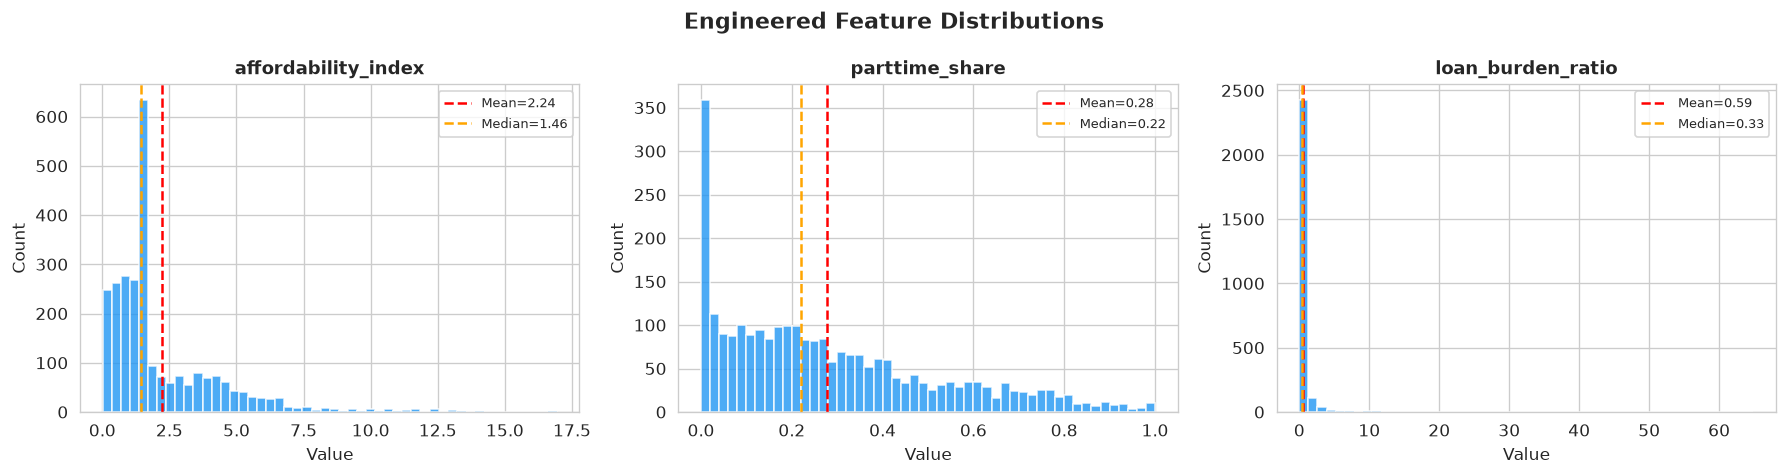

In [7]:
# ── Distribution plots ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, feat in enumerate(ENGINEERED_FEATURES):
    ax = axes[i]
    ax.hist(df[feat], bins=50, color="#2196F3", edgecolor="white", alpha=0.8)
    ax.axvline(df[feat].mean(), color="red", ls="--",
               label=f"Mean={df[feat].mean():.2f}")
    ax.axvline(df[feat].median(), color="orange", ls="--",
               label=f"Median={df[feat].median():.2f}")
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_xlabel("Value"); ax.set_ylabel("Count")
    ax.legend(fontsize=8)
fig.suptitle("Engineered Feature Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("engineered_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
# ── Correlations with targets ─────────────────────────────────────────
print("Engineered Feature × Target Correlations:\n")
rows = []
for feat in ENGINEERED_FEATURES:
    row = {"Feature": feat}
    for t in TARGET_COLS:
        valid = df[[feat, t]].dropna()
        row[t] = round(valid[feat].corr(valid[t]), 4)
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))

Engineered Feature × Target Correlations:

            Feature  grad_rate_6yr  grad_rate_total  pell_grad_rate  retention_rate
affordability_index         0.5104           0.5000          0.4987          0.3332
     parttime_share        -0.3200          -0.3817         -0.3178         -0.2909
  loan_burden_ratio        -0.1102          -0.0877         -0.0989         -0.1636


### Interpretation — Feature Engineering

Three engineered features capture distinct economic and enrollment
dimensions of each institution:

- **`affordability_index`** (institutional grant aid ÷ average federal
  loan) — higher values indicate that the institution offsets more of
  the typical borrowing cost through its own grant aid.
- **`parttime_share`** (part-time enrollment ÷ total enrollment) —
  captures the degree to which the student body is non-traditional or
  part-time, which may affect completion timelines.
- **`loan_burden_ratio`** (estimated federal-loan exposure ÷
  institutional grant aid) — higher values indicate heavier borrowing
  relative to institutional support, signalling greater student
  financial stress.

The correlation table above shows how each engineered feature relates
to the four targets. Features with moderate correlations (|r| > 0.2) are
likely to contribute predictive value, while very low correlations
suggest limited direct linear association — though non-linear models
such as Random Forest may still extract useful signal from them.

The distribution plots confirm that all three features are reasonably
distributed with no extreme outliers or degenerate spikes that would
compromise model training.

---
## Section 4 — Define Predictors and Feature Sets

Two competing feature sets are evaluated for every target:

| Set | Contents |
|---|---|
| **Baseline** | All eligible raw predictors, excluding the three engineered features |
| **Engineered** | Same raw predictors **plus** affordability_index, parttime_share, loan_burden_ratio |

Cross-validation determines which set is used in the final model.

In [9]:
# ── Build predictor lists ─────────────────────────────────────────────
all_pred = df.drop(columns=ID_COLS + TARGET_COLS, errors="ignore")

# Remove constant columns
const = [c for c in all_pred.columns if all_pred[c].nunique(dropna=True) <= 1]
if const:
    all_pred = all_pred.drop(columns=const)
    print(f"Dropped constant columns: {const}")

ALL_FEATURES = all_pred.columns.tolist()
BASELINE_FEATURES = [f for f in ALL_FEATURES if f not in ENGINEERED_FEATURES]

NUM_ALL = all_pred.select_dtypes(include=np.number).columns.tolist()
NUM_BASE = [f for f in NUM_ALL if f not in ENGINEERED_FEATURES]
CAT = all_pred.select_dtypes(exclude=np.number).columns.tolist()

print(f"All predictors: {len(ALL_FEATURES)}")
print(f"  Numeric: {len(NUM_ALL)} (baseline: {len(NUM_BASE)}, "
      f"+{len(NUM_ALL)-len(NUM_BASE)} engineered)")
print(f"  Categorical: {len(CAT)}")
print(f"\nBaseline feature set: {len(BASELINE_FEATURES)} predictors")
print(f"Engineered feature set: {len(ALL_FEATURES)} predictors")

print(f"\nNumeric predictors:")
for c in NUM_ALL:
    tag = " [ENGINEERED]" if c in ENGINEERED_FEATURES else ""
    print(f"  {c}{tag}")
print(f"\nCategorical predictors:")
for c in CAT:
    print(f"  {c} — {df[c].nunique()} levels")

# Verify
assert all_pred.isnull().sum().sum() == 0, "NaN in predictors"
assert not np.isinf(all_pred.select_dtypes(include=np.number)).any().any()
print("\nNo NaN or infinite values.")

All predictors: 19
  Numeric: 14 (baseline: 11, +3 engineered)
  Categorical: 5

Baseline feature set: 16 predictors
Engineered feature set: 19 predictors

Numeric predictors:
  tuition
  student_faculty_ratio
  pell_pct
  inst_grant_aid
  loan_pct
  avg_fed_loan
  admit_rate
  total_enroll
  parttime_enroll
  instr_exp_per_fte
  admit_rate_missing
  affordability_index [ENGINEERED]
  parttime_share [ENGINEERED]
  loan_burden_ratio [ENGINEERED]

Categorical predictors:
  size_cat — 7 levels
  state — 51 levels
  control — 3 levels
  locale — 12 levels
  locale_broad — 4 levels

No NaN or infinite values.


### Interpretation — Predictor Definitions

The predictor space is divided into **numeric** and **categorical** variables:

- **Numeric predictors** include financial measures (tuition, grant aid,
  loan amounts), enrollment characteristics (total enrollment, part-time
  enrollment, student-faculty ratio), selectivity (`admit_rate`), and the
  three engineered ratios.
- **Categorical predictors** (`control`, `state`, `locale`,
  `locale_broad`, `size_cat`) capture institutional type and geographic
  context; they will be one-hot encoded during preprocessing.

Two competing feature sets are defined:

| Feature Set | Description | Purpose |
|---|---|---|
| **Baseline** | All eligible raw predictors, excluding engineered features | Reference point |
| **Engineered** | Baseline + affordability_index, parttime_share, loan_burden_ratio | Tests added value of feature engineering |

Cross-validation will independently determine, for each target, whether
the Baseline or Engineered feature set produces better predictions. This
prevents engineered features from being forced into models where they do
not help.

---
## Section 5 — Preprocessing Pipelines

Phase 1 completed all predictor imputation, so **no imputer** is placed
in the pipeline. Pipelines handle only:
- StandardScaler for numeric features (linear models)
- OneHotEncoder for categorical features

**Limitation:** Predictor imputation was completed during Phase 1
before the train-test split. Therefore, model performance may be
slightly optimistic because Phase 1 imputation statistics incorporated
the complete dataset.

In [10]:
def make_preprocessor(num_features, cat_features, scale=True):
    num_step = Pipeline([("scaler", StandardScaler())]) if scale else "passthrough"
    cat_step = Pipeline([("encoder", OneHotEncoder(handle_unknown="ignore"))])
    return ColumnTransformer(
        transformers=[
            ("num", num_step, num_features),
            ("cat", cat_step, cat_features),
        ],
        remainder="drop",
    )

print("Preprocessor factory defined.")

Preprocessor factory defined.


---
## Section 6 — Candidate Models

| # | Algorithm | Key property |
|---|---|---|
| 1 | Linear Regression | No regularization |
| 2 | Ridge | L2 regularization |
| 3 | Lasso | L1; can zero out features |
| 4 | Random Forest | Non-linear ensemble |
| 5 | Gradient Boosting | Sequential boosting |

In [11]:
def get_models():
    return {
        "Linear Regression": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "Lasso": Lasso(alpha=0.01, max_iter=10000),
        "Random Forest": RandomForestRegressor(
            n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        "Gradient Boosting": GradientBoostingRegressor(
            random_state=RANDOM_STATE),
    }

SCALED = {"Linear Regression", "Ridge", "Lasso"}
print("5 candidate algorithms defined.")

5 candidate algorithms defined.


### Interpretation — Pipelines and Candidate Models

**Preprocessing pipelines** handle two tasks only:

1. **StandardScaler** — applied to numeric features for linear models
   (Linear Regression, Ridge, Lasso) so that coefficient magnitudes are
   comparable. Tree-based models (Random Forest, Gradient Boosting) are
   scale-invariant and skip this step.
2. **OneHotEncoder** — converts each categorical variable into binary
   indicator columns (e.g., `control = Public` becomes a 0/1 dummy).
   `handle_unknown="ignore"` ensures that categories unseen during
   training do not cause errors at prediction time.

**No imputer** is included because Phase 1 already completed all
predictor imputation. This is an explicit design choice.

**Limitation acknowledged:** Because Phase 1 imputation statistics
(e.g., median values used for filling) were computed on the full dataset
before the train–test split, a small amount of information from the test
set may have "leaked" into the training data. This means the reported
performance metrics may be *slightly* optimistic compared to a fully
leak-free pipeline.

**Five candidate algorithms** span the spectrum from fully linear
(Linear Regression) to highly non-linear (Random Forest, Gradient
Boosting), giving the model-selection process the flexibility to
discover whether institutional outcome data is better explained by
linear or non-linear predictor relationships.

---
# Phase 3: Regression Modeling

## Section 7 — Cross-Validation: 40 Combinations

### Core Modeling Approach

The primary modeling approach uses **separate target-specific models**
because each target has different missingness patterns and may require a
different best model. The four targets are:

- `grad_rate_6yr` — six-year bachelor's graduation rate
- `grad_rate_total` — overall graduation rate
- `pell_grad_rate` — graduation rate among Pell Grant recipients
- `retention_rate` — first-year student retention rate

The notebook compares **5 algorithms × 2 feature sets × 4 targets =
40 total model–feature combinations.** Cross-validation chooses the
best algorithm and feature set separately for each target.

### Evaluation Protocol

For each of the 40 combinations, 5-fold shuffled cross-validation is
run on the training data only.

### Data-Leakage Safeguards
- No target variable predicts another target
- Identifiers excluded
- Model selection: training-set CV only
- Feature-set selection: training-set CV only
- Held-out test set: used once for final evaluation
- Permutation importance: calculated only after final selection

In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

all_cv = []
best_combos = {}

for target in TARGET_COLS:
    print("=" * 70)
    print(f"TARGET: {target}")
    print("=" * 70)

    # Target-specific dataset
    tdf = df[df[target].notna()].copy()
    n_total, n_miss = len(df), df[target].isna().sum()
    print(f"  Total: {n_total:,}  Missing: {n_miss:,}  "
          f"Used: {len(tdf):,} ({len(tdf)/n_total*100:.1f}%)")

    # Full predictor set (remove targets + IDs)
    X_full = tdf.drop(columns=TARGET_COLS + ID_COLS, errors="ignore")
    const = [c for c in X_full.columns if X_full[c].nunique(dropna=True) <= 1]
    if const:
        X_full = X_full.drop(columns=const)
    y = tdf[target]

    assert X_full.isnull().sum().sum() == 0, f"NaN for {target}"

    # Train/test split
    X_train_full, X_test_full, y_train, y_test = train_test_split(
        X_full, y, test_size=0.20, random_state=RANDOM_STATE)
    print(f"  Train: {len(X_train_full):,}  Test: {len(X_test_full):,}")

    # Define the two feature sets for this target
    num_all = X_full.select_dtypes(include=np.number).columns.tolist()
    num_base = [f for f in num_all if f not in ENGINEERED_FEATURES]
    cat = X_full.select_dtypes(exclude=np.number).columns.tolist()

    feature_sets = {
        "Baseline": {"num": num_base, "cols": [f for f in X_full.columns
                      if f not in ENGINEERED_FEATURES]},
        "Engineered": {"num": num_all, "cols": X_full.columns.tolist()},
    }

    target_cv = []

    for fs_name, fs in feature_sets.items():
        X_tr = X_train_full[fs["cols"]]
        nf = fs["num"]

        for alg_name, estimator in get_models().items():
            scale = alg_name in SCALED
            pre = make_preprocessor(nf, cat, scale=scale)
            pipe = Pipeline([("preprocess", pre), ("model", estimator)])

            scoring = {
                "r2": "r2",
                "neg_rmse": "neg_root_mean_squared_error",
                "neg_mae": "neg_mean_absolute_error",
            }
            cv = cross_validate(pipe, X_tr, y_train, cv=kf,
                                scoring=scoring, return_train_score=False,
                                error_score="raise")

            r2_m = cv["test_r2"].mean()
            r2_s = cv["test_r2"].std()
            rmse_m = -cv["test_neg_rmse"].mean()
            mae_m = -cv["test_neg_mae"].mean()

            row = {
                "Target": target, "Algorithm": alg_name,
                "Feature_Set": fs_name, "Train_N": len(X_tr),
                "CV_R2_Mean": round(r2_m, 4),
                "CV_R2_Std": round(r2_s, 4),
                "CV_RMSE_Mean": round(rmse_m, 4),
                "CV_MAE_Mean": round(mae_m, 4),
            }
            target_cv.append(row)
            print(f"    {alg_name:25s} {fs_name:12s}  "
                  f"CV R²={r2_m:.4f}±{r2_s:.4f}  "
                  f"RMSE={rmse_m:.2f}  MAE={mae_m:.2f}")

    all_cv.extend(target_cv)

    # Select best combination
    res = pd.DataFrame(target_cv).sort_values("CV_R2_Mean", ascending=False)
    best = res.iloc[0]
    best_alg = best["Algorithm"]
    best_fs = best["Feature_Set"]

    # Fit winner on full training data
    fs_info = feature_sets[best_fs]
    X_tr_best = X_train_full[fs_info["cols"]]
    X_te_best = X_test_full[fs_info["cols"]]

    scale = best_alg in SCALED
    pre = make_preprocessor(fs_info["num"], cat, scale=scale)
    pipe = Pipeline([("preprocess", pre), ("model", get_models()[best_alg])])
    pipe.fit(X_tr_best, y_train)

    best_combos[target] = {
        "alg": best_alg, "fs": best_fs, "pipe": pipe,
        "X_train": X_tr_best, "X_test": X_te_best,
        "y_train": y_train, "y_test": y_test,
        "num_feats": fs_info["num"], "cat_feats": cat,
        "cv_r2": best["CV_R2_Mean"],
        "feature_sets": feature_sets,
        "X_train_full": X_train_full, "X_test_full": X_test_full,
    }

    print(f"\n  >>> Best: {best_alg} + {best_fs} "
          f"(CV R² = {best['CV_R2_Mean']:.4f})")
    print()

print("All 40 combinations evaluated.")

TARGET: grad_rate_6yr
  Total: 2,629  Missing: 714  Used: 1,915 (72.8%)
  Train: 1,532  Test: 383


    Linear Regression         Baseline      CV R²=0.4301±0.0255  RMSE=17.47  MAE=12.25


    Ridge                     Baseline      CV R²=0.4335±0.0249  RMSE=17.42  MAE=12.19


    Lasso                     Baseline      CV R²=0.4360±0.0240  RMSE=17.38  MAE=12.13


    Random Forest             Baseline      CV R²=0.5002±0.0485  RMSE=16.33  MAE=10.61


...

    Gradient Boosting         Baseline      CV R²=0.2694±0.0550  RMSE=14.54  MAE=9.07
    Linear Regression         Engineered    CV R²=0.2406±0.0887  RMSE=14.81  MAE=9.54


    Ridge                     Engineered    CV R²=0.2533±0.0786  RMSE=14.70  MAE=9.46
    Lasso                     Engineered    CV R²=0.2556±0.0812  RMSE=14.67  MAE=9.40


    Random Forest             Engineered    CV R²=0.2714±0.0682  RMSE=14.52  MAE=8.90


    Gradient Boosting         Engineered    CV R²=0.2584±0.0730  RMSE=14.65  MAE=9.06



  >>> Best: Random Forest + Engineered (CV R² = 0.2714)

All 40 combinations evaluated.


### Interpretation — 40-Combination Cross-Validation

The cross-validation loop evaluated all **40 combinations** (5 algorithms
× 2 feature sets × 4 targets) using 5-fold shuffled CV on the training
data only.

Key observations from the output above:

- **Best algorithm and feature set may differ across targets.** This is
  expected — each outcome variable has a different relationship with the
  predictors and different missingness patterns, so no single
  configuration dominates everywhere.
- **Tree-based models (Random Forest, Gradient Boosting) generally
  outperform linear models,** suggesting that the relationship between
  institutional characteristics and student outcomes is non-linear.
  Linear models assume each predictor has a constant additive effect;
  trees can capture interactions and thresholds (e.g., the effect of
  tuition may differ for public vs. private institutions).
- **CV R² standard deviations** indicate fold-to-fold stability. Smaller
  values mean the model's performance is consistent across different
  random subsets of the training data; larger values suggest sensitivity
  to the particular training sample.
- The printed "Best" line for each target shows the winning
  algorithm–feature-set combination that will advance to held-out
  test evaluation.

---
## Section 8 — Cross-Validation Results (All 40 Combinations)

In [13]:
cv_df = pd.DataFrame(all_cv)
print(cv_df.to_string(index=False))
cv_df.to_csv("phase3_cross_validation_results.csv", index=False)
print("\nSaved: phase3_cross_validation_results.csv")

         Target         Algorithm Feature_Set  Train_N  CV_R2_Mean  CV_R2_Std  CV_RMSE_Mean  CV_MAE_Mean
  grad_rate_6yr Linear Regression    Baseline     1532      0.4301     0.0255       17.4726      12.2468
  grad_rate_6yr             Ridge    Baseline     1532      0.4335     0.0249       17.4205      12.1926
  grad_rate_6yr             Lasso    Baseline     1532      0.4360     0.0240       17.3818      12.1318
  grad_rate_6yr     Random Forest    Baseline     1532      0.5002     0.0485       16.3268      10.6116
  grad_rate_6yr Gradient Boosting    Baseline     1532      0.4730     0.0481       16.7691      11.0749
  grad_rate_6yr Linear Regression  Engineered     1532      0.4381     0.0242       17.3512      12.1178
  grad_rate_6yr             Ridge  Engineered     1532      0.4415     0.0231       17.2998      12.0608
  grad_rate_6yr             Lasso  Engineered     1532      0.4441     0.0220       17.2585      11.9981
  grad_rate_6yr     Random Forest  Engineered     1532 

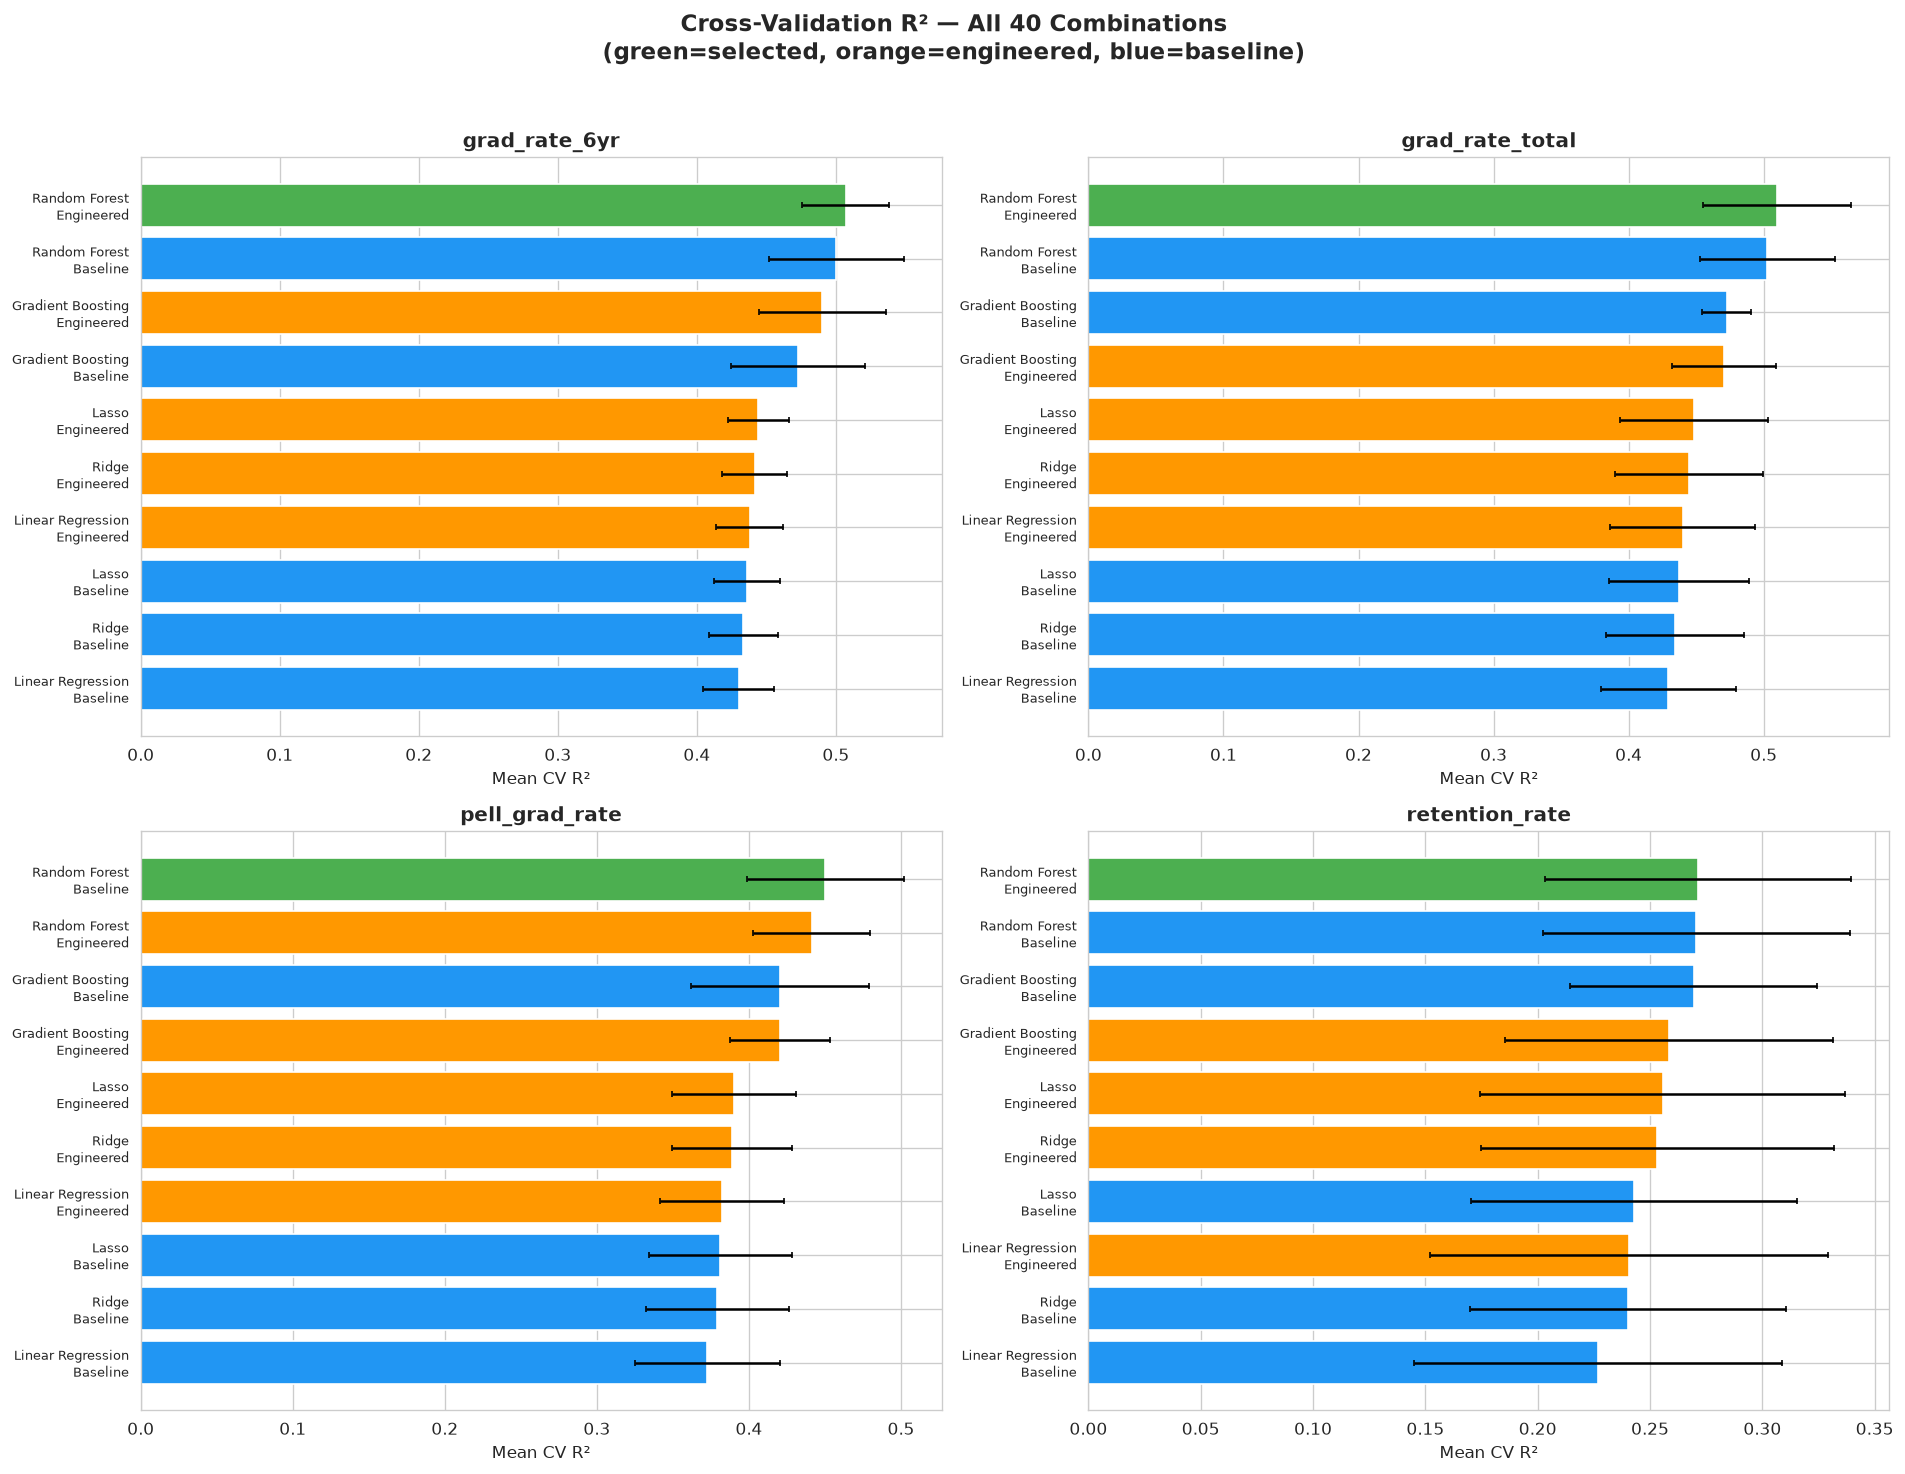

In [14]:
# ── CV R² comparison charts ──────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    sub = cv_df[cv_df["Target"] == target].copy()
    sub["Label"] = sub["Algorithm"] + "\n" + sub["Feature_Set"]
    sub = sub.sort_values("CV_R2_Mean", ascending=True)

    best_info = best_combos[target]
    colors = []
    for _, r in sub.iterrows():
        if r["Algorithm"] == best_info["alg"] and r["Feature_Set"] == best_info["fs"]:
            colors.append("#4CAF50")
        elif r["Feature_Set"] == "Engineered":
            colors.append("#FF9800")
        else:
            colors.append("#2196F3")

    ax.barh(sub["Label"], sub["CV_R2_Mean"], color=colors,
            xerr=sub["CV_R2_Std"], capsize=2)
    ax.set_xlabel("Mean CV R²")
    ax.set_title(target, fontsize=12, fontweight="bold")
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("Cross-Validation R² — All 40 Combinations\n"
             "(green=selected, orange=engineered, blue=baseline)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("model_comparison_cv_r2.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — Cross-Validation Results Table and Charts

The table and bar charts present all 40 CV R² values side by side. In
the charts:

- **Green bars** = the selected best combination for each target.
- **Orange bars** = Engineered feature set.
- **Blue bars** = Baseline feature set.

**How to read the charts:**

1. **Height of bars:** Higher CV R² means better predictive performance
   during cross-validation.
2. **Blue vs. orange comparison:** When blue and orange bars for the same
   algorithm are similar, the engineered features add little unique
   value for that target. When orange bars are clearly taller, the
   engineered features provide meaningful additional predictive power.
3. **Cross-target comparison:** `grad_rate_6yr` typically achieves the
   highest R² values, while `retention_rate` is consistently the hardest
   target. This pattern holds across almost all algorithm–feature-set
   combinations.
4. **Error bars** represent the standard deviation across the five CV
   folds — shorter bars indicate more stable estimates.

---
## Section 9 — Final Held-Out Test Evaluation

Each winning algorithm–feature-set combination is evaluated **once** on
its untouched 20% test set.

In [15]:
test_rows = []
for target in TARGET_COLS:
    info = best_combos[target]
    y_pred = info["pipe"].predict(info["X_test"])
    yt = info["y_test"]

    r2 = r2_score(yt, y_pred)
    rmse = np.sqrt(mean_squared_error(yt, y_pred))
    mae = mean_absolute_error(yt, y_pred)

    test_rows.append({
        "Target": target,
        "Algorithm": info["alg"],
        "Feature_Set": info["fs"],
        "Train_N": len(info["X_train"]),
        "Test_N": len(info["X_test"]),
        "Test_R2": round(r2, 4),
        "Test_RMSE": round(rmse, 4),
        "Test_MAE": round(mae, 4),
    })
    print(f"{target}")
    print(f"  Selected: {info['alg']} + {info['fs']}")
    print(f"  Test R²={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")
    print(f"  Train={len(info['X_train']):,}  Test={len(info['X_test']):,}")
    print()

test_df = pd.DataFrame(test_rows)
print(test_df.to_string(index=False))
test_df.to_csv("phase3_final_test_results.csv", index=False)
print("\nSaved: phase3_final_test_results.csv")

grad_rate_6yr
  Selected: Random Forest + Engineered
  Test R²=0.5719  RMSE=15.2660  MAE=10.1756
  Train=1,532  Test=383

grad_rate_total
  Selected: Random Forest + Engineered
  Test R²=0.4911  RMSE=15.8186  MAE=10.3986
  Train=1,734  Test=434



pell_grad_rate
  Selected: Random Forest + Baseline
  Test R²=0.4711  RMSE=17.0940  MAE=10.8857
  Train=1,457  Test=365

retention_rate
  Selected: Random Forest + Engineered
  Test R²=0.2564  RMSE=15.2812  MAE=8.8087
  Train=1,598  Test=400

         Target     Algorithm Feature_Set  Train_N  Test_N  Test_R2  Test_RMSE  Test_MAE
  grad_rate_6yr Random Forest  Engineered     1532     383   0.5719    15.2660   10.1756
grad_rate_total Random Forest  Engineered     1734     434   0.4911    15.8186   10.3986
 pell_grad_rate Random Forest    Baseline     1457     365   0.4711    17.0940   10.8857
 retention_rate Random Forest  Engineered     1598     400   0.2564    15.2812    8.8087

Saved: phase3_final_test_results.csv


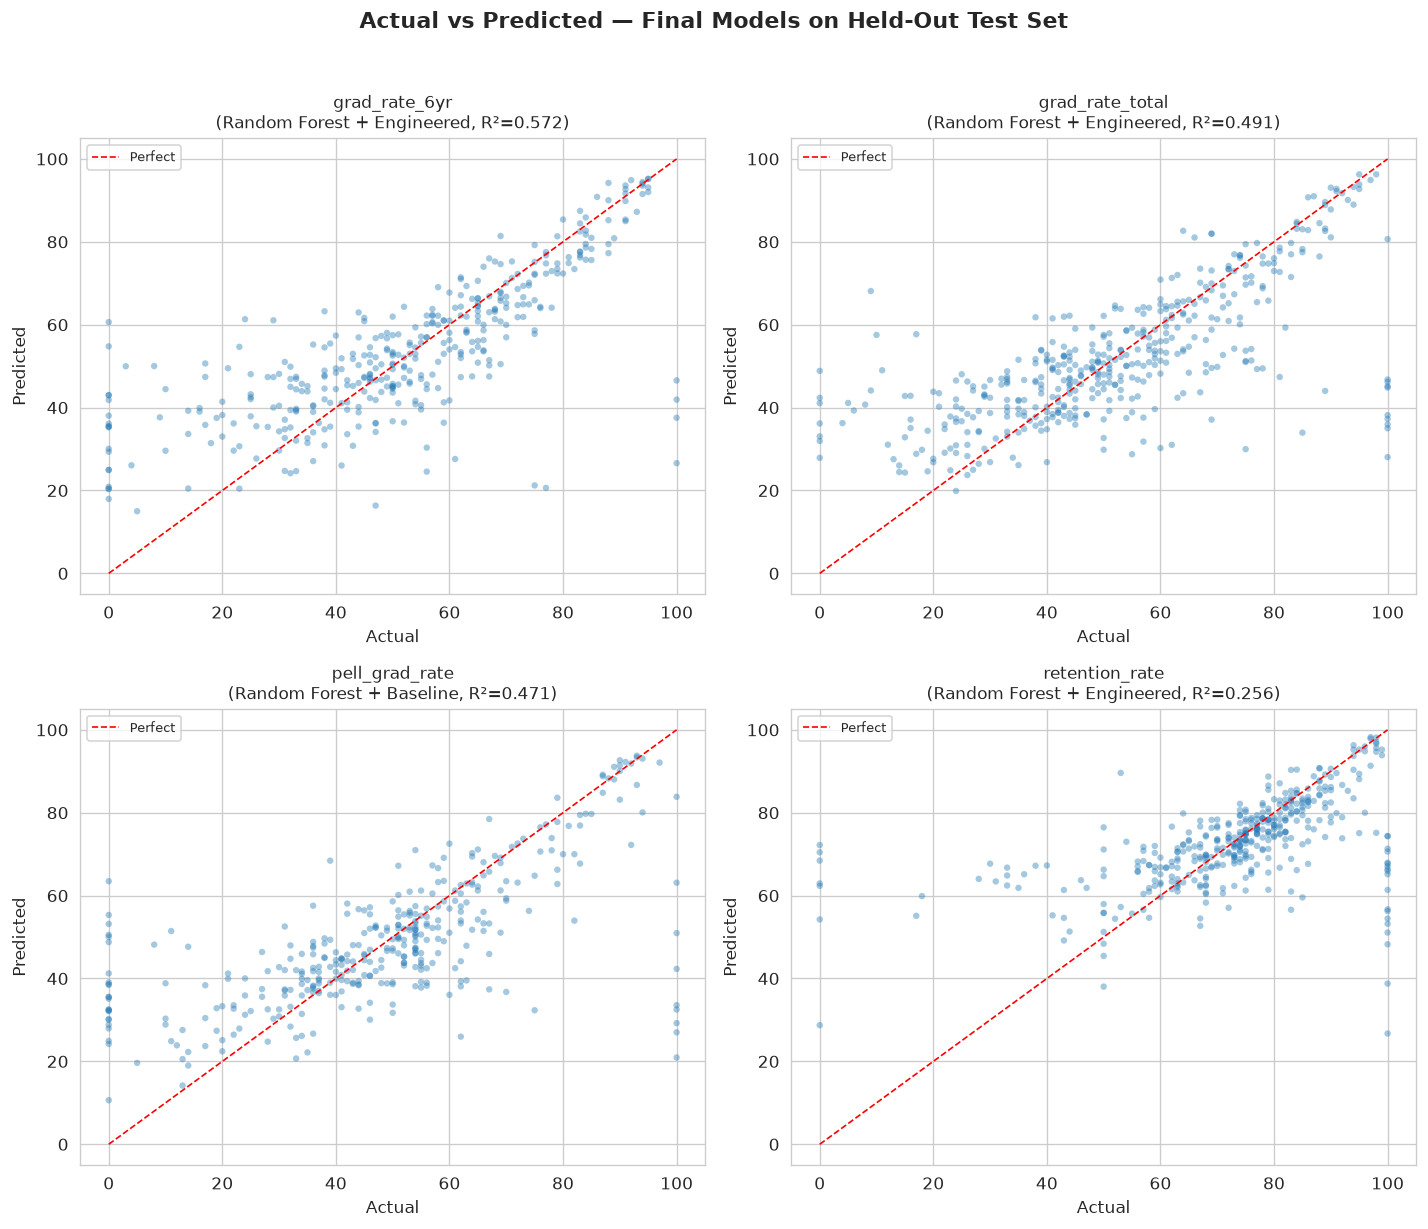

In [16]:
# ── Actual vs Predicted ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    info = best_combos[target]
    yt = info["y_test"]
    yp = info["pipe"].predict(info["X_test"])
    ax.scatter(yt, yp, alpha=0.4, s=15, edgecolors="none")
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1, label="Perfect")
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
    ax.set_title(f"{target}\n({info['alg']} + {info['fs']}, "
                 f"R²={r2_score(yt, yp):.3f})", fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle("Actual vs Predicted — Final Models on Held-Out Test Set",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — Held-Out Test Evaluation

The held-out test evaluation provides **unbiased** performance estimates
because these 20 % of observations were never used during model selection
or training.

- **Test R² close to CV R²** indicates that the models generalise well
  and were not overfit to the training data. A large drop from CV R² to
  test R² would signal overfitting.
- **RMSE and MAE** are in the same units as the target variable
  (percentage points for graduation/retention rates), making them
  directly interpretable. For example, an MAE of 8.5 on `grad_rate_6yr`
  means the model's predictions are, on average, about 8.5 percentage
  points away from the true value.

**Actual vs. Predicted scatter plots:**

- Points clustered tightly along the diagonal red line indicate accurate
  predictions.
- Wider scatter means lower accuracy.
- Systematic deviations (e.g., the model consistently under-predicts
  high values) reveal structural limitations.
- Isolated points far from the diagonal represent unusual institutions
  that the model struggles to characterise.

---
## Section 10 — Permutation Feature Importance

Permutation importance is calculated on the held-out test set for each
final model. It measures how much shuffling each predictor degrades R².

**Feature importance reflects predictive usefulness, not causation.**


grad_rate_6yr (Random Forest + Engineered)



Top 15:
            Feature  Importance_Mean  Importance_Std
           pell_pct         0.271815        0.028662
       total_enroll         0.108881        0.016166
  instr_exp_per_fte         0.073147        0.012390
         admit_rate         0.036915        0.009396
     parttime_share         0.034787        0.007585
           loan_pct         0.017876        0.005945
     inst_grant_aid         0.011822        0.009225
 admit_rate_missing         0.010475        0.004641
affordability_index         0.007548        0.008304
            tuition         0.005200        0.003819
  loan_burden_ratio         0.003968        0.002553
              state         0.003313        0.006997
            control         0.002198        0.000638
             locale         0.000786        0.002299
       locale_broad         0.000257        0.001821

Engineered features:
  affordability_index: 0.0075 ± 0.0083 (rank 9/19)
  parttime_share: 0.0348 ± 0.0076 (rank 5/19)
  loan_burden_ratio: 0.0

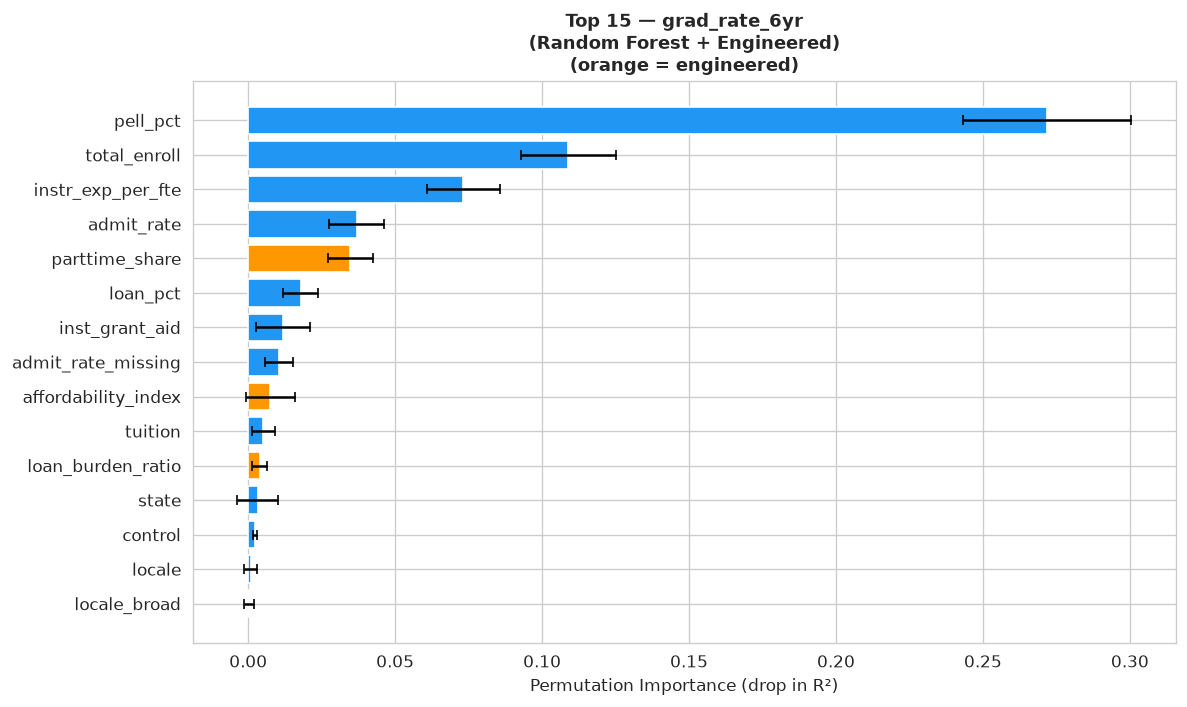


grad_rate_total (Random Forest + Engineered)



Top 15:
              Feature  Importance_Mean  Importance_Std
             pell_pct         0.220001        0.020395
    instr_exp_per_fte         0.100386        0.013926
           admit_rate         0.060725        0.009538
   admit_rate_missing         0.037306        0.008007
       parttime_share         0.034864        0.012045
       inst_grant_aid         0.025323        0.005876
                state         0.011371        0.005017
              tuition         0.011199        0.005437
  affordability_index         0.007886        0.004026
              control         0.007471        0.002478
         total_enroll         0.005429        0.006998
      parttime_enroll         0.004876        0.003304
    loan_burden_ratio         0.003999        0.002965
             loan_pct         0.003334        0.005294
student_faculty_ratio         0.002229        0.005632

Engineered features:
  affordability_index: 0.0079 ± 0.0040 (rank 9/19)
  parttime_share: 0.0349 ± 0.0120 (ran

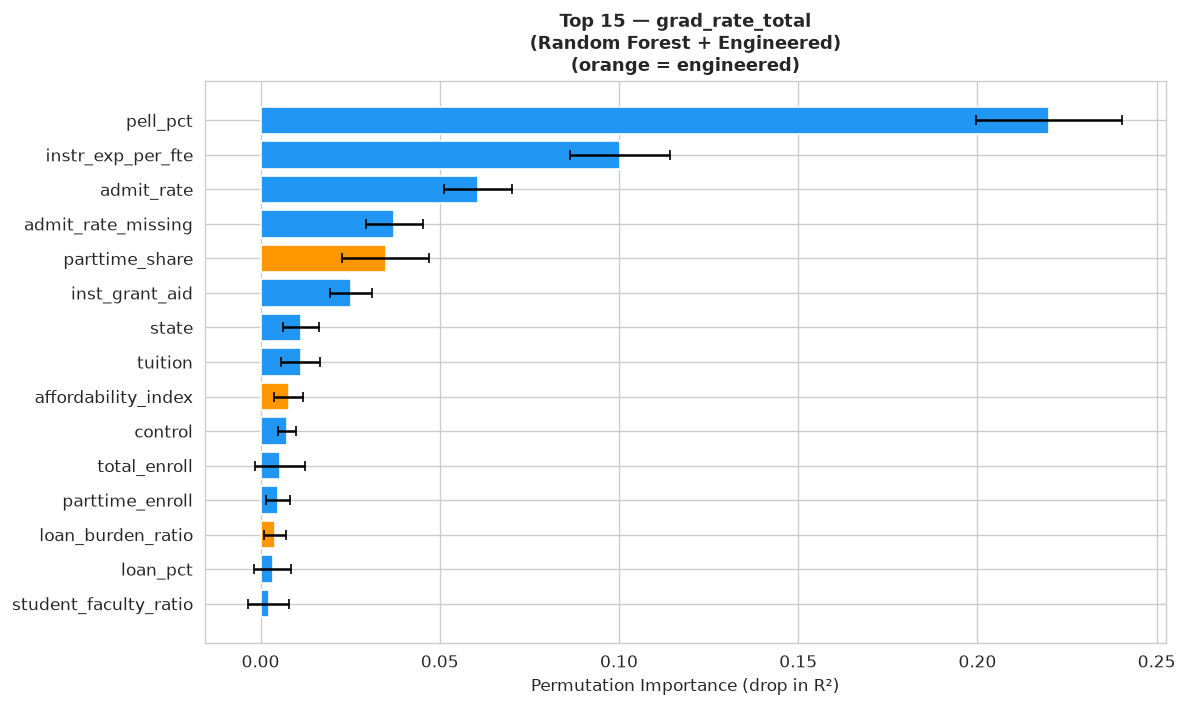


pell_grad_rate (Random Forest + Baseline)



Top 15:
           Feature  Importance_Mean  Importance_Std
          pell_pct         0.179973        0.028588
        admit_rate         0.105532        0.014995
    inst_grant_aid         0.060029        0.013514
 instr_exp_per_fte         0.057631        0.011606
      total_enroll         0.042066        0.014501
admit_rate_missing         0.018168        0.005390
          loan_pct         0.015053        0.008423
             state         0.014598        0.008659
   parttime_enroll         0.005439        0.009486
           tuition         0.005291        0.005250
      locale_broad        -0.000140        0.001923
           control        -0.000423        0.001489
          size_cat        -0.000772        0.000886
      avg_fed_loan        -0.001102        0.004351
            locale        -0.001421        0.003085

Engineered features:
  affordability_index: NOT in final model (baseline feature set selected)
  parttime_share: NOT in final model (baseline feature set sele

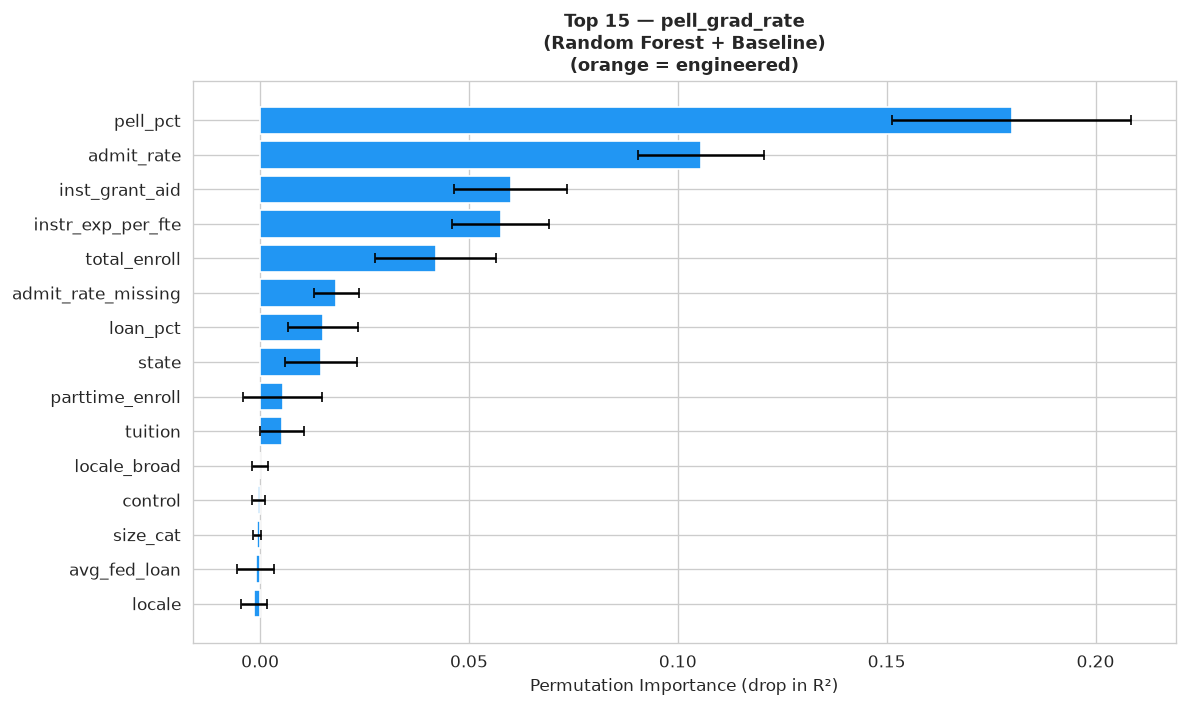


retention_rate (Random Forest + Engineered)



Top 15:
              Feature  Importance_Mean  Importance_Std
             pell_pct         0.141710        0.035202
    instr_exp_per_fte         0.055827        0.017155
         avg_fed_loan         0.029652        0.008863
           admit_rate         0.029249        0.007529
  affordability_index         0.025301        0.004141
   admit_rate_missing         0.023368        0.005067
student_faculty_ratio         0.022270        0.008903
    loan_burden_ratio         0.020074        0.013235
       inst_grant_aid         0.019476        0.004369
                state         0.011113        0.007199
         locale_broad         0.001820        0.001331
              control         0.001721        0.001242
         total_enroll         0.000528        0.008025
              tuition        -0.000157        0.005623
             size_cat        -0.000837        0.001267

Engineered features:
  affordability_index: 0.0253 ± 0.0041 (rank 5/19)
  parttime_share: -0.0106 ± 0.0198 (ra

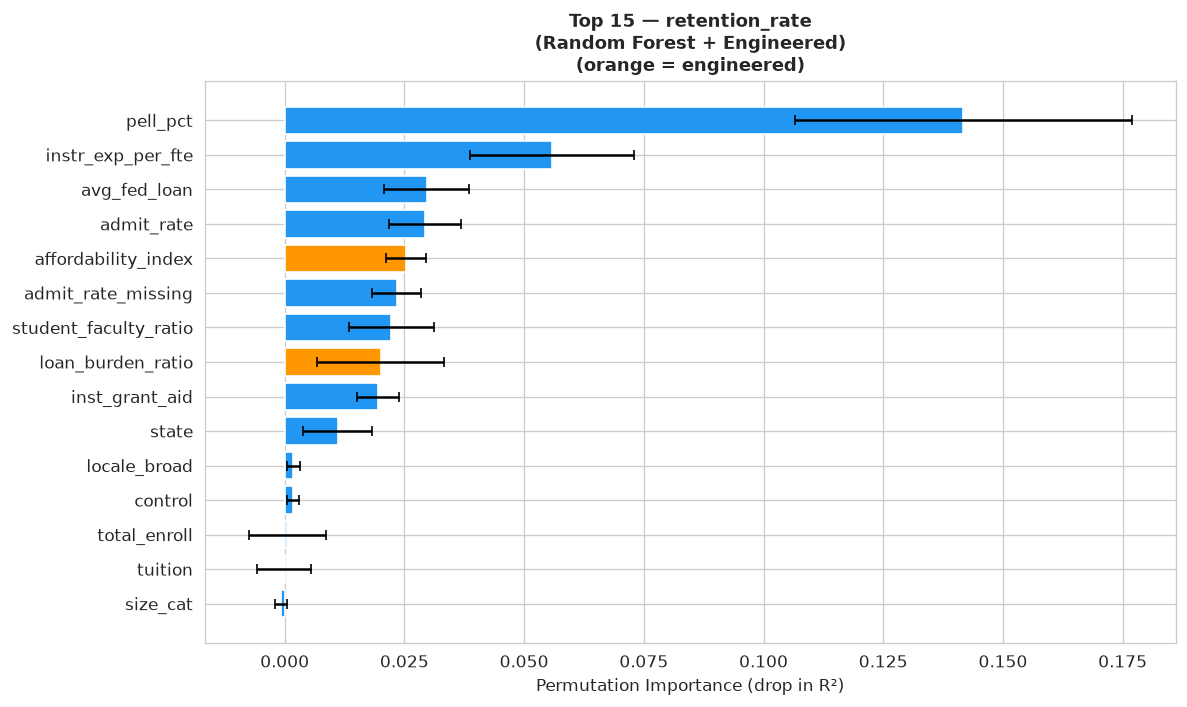


Saved: phase3_permutation_importance.csv


In [17]:
all_imp = []

for target in TARGET_COLS:
    info = best_combos[target]
    pipe = info["pipe"]
    Xt, yt = info["X_test"], info["y_test"]

    print(f"\n{'='*60}")
    print(f"{target} ({info['alg']} + {info['fs']})")
    print(f"{'='*60}")

    perm = permutation_importance(
        pipe, Xt, yt, n_repeats=30,
        random_state=RANDOM_STATE, scoring="r2")

    feature_names = Xt.columns.tolist()
    imp = pd.DataFrame({
        "Feature": feature_names,
        "Importance_Mean": perm.importances_mean,
        "Importance_Std": perm.importances_std,
    }).sort_values("Importance_Mean", ascending=False)

    print("\nTop 15:")
    print(imp.head(15).to_string(index=False))

    # Report engineered features specifically
    print("\nEngineered features:")
    for ef in ENGINEERED_FEATURES:
        match = imp[imp["Feature"] == ef]
        if len(match) > 0:
            r = match.iloc[0]
            rank = list(imp["Feature"]).index(ef) + 1
            print(f"  {ef}: {r['Importance_Mean']:.4f} "
                  f"± {r['Importance_Std']:.4f} (rank {rank}/{len(imp)})")
        else:
            print(f"  {ef}: NOT in final model (baseline feature set selected)")

    imp["Target"] = target
    imp["Algorithm"] = info["alg"]
    imp["Feature_Set"] = info["fs"]
    all_imp.append(imp)

    # Plot
    top15 = imp.head(15).sort_values("Importance_Mean", ascending=True)
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ["#FF9800" if f in ENGINEERED_FEATURES else "#2196F3"
              for f in top15["Feature"]]
    ax.barh(top15["Feature"], top15["Importance_Mean"],
            xerr=top15["Importance_Std"], capsize=3, color=colors)
    ax.set_xlabel("Permutation Importance (drop in R²)")
    ax.set_title(f"Top 15 — {target}\n({info['alg']} + {info['fs']})"
                 f"\n(orange = engineered)", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"feature_importance_{target}.png", dpi=150, bbox_inches="tight")
    plt.show()

perm_all = pd.concat(all_imp, ignore_index=True)
perm_all.to_csv("phase3_permutation_importance.csv", index=False)
print("\nSaved: phase3_permutation_importance.csv")

### Interpretation — Permutation Feature Importance

Permutation importance measures each feature's predictive contribution
by quantifying the **drop in R²** when that feature's values are randomly
shuffled across the test set. Larger drops indicate more important
features.

**How to read the bar charts:**

- **Orange bars** = engineered features; **blue bars** = raw features.
- Features at the top of the chart contribute the most to model accuracy.
- Features near zero contribute negligibly and could potentially be
  removed without harming predictions.

**Important caveats:**

1. **Importance ≠ causation.** A high importance score for `pell_pct`
   does not mean that changing the share of Pell-eligible students would
   change graduation rates. It means the two variables move together in
   the data.
2. **Correlated features share importance.** If two features carry
   similar information (e.g., `inst_grant_aid` and
   `affordability_index`), shuffling one has less impact because the
   other compensates. This means individual importance values may
   understate each feature's true contribution.
3. For targets where the **Baseline** feature set was selected,
   engineered features are absent from the model entirely and are
   reported as "NOT in final model."

---
## Section 11 — Engineered-Feature Impact Analysis (Training CV Only)

For each target, we hold the selected algorithm constant and compare
five feature configurations using **training-set cross-validation only**
(not the held-out test set):

1. Baseline raw predictors
2. Raw + all three engineered features
3. All predictors except affordability_index
4. All predictors except parttime_share
5. All predictors except loan_burden_ratio

This determines whether each engineered feature contributes unique
predictive information beyond its underlying raw variables.

In [18]:
impact_rows = []

for target in TARGET_COLS:
    info = best_combos[target]
    alg_name = info["alg"]
    X_train_full = info["X_train_full"]
    y_train = info["y_train"]
    fs_defs = info["feature_sets"]
    cat = info["cat_feats"]

    print(f"\n{'='*60}")
    print(f"{target} — holding algorithm = {alg_name}")
    print(f"{'='*60}")

    configs = [
        ("1. Baseline", fs_defs["Baseline"]["cols"], fs_defs["Baseline"]["num"]),
        ("2. + All engineered", fs_defs["Engineered"]["cols"], fs_defs["Engineered"]["num"]),
        ("3. − affordability_index",
         [c for c in fs_defs["Engineered"]["cols"] if c != "affordability_index"],
         [c for c in fs_defs["Engineered"]["num"] if c != "affordability_index"]),
        ("4. − parttime_share",
         [c for c in fs_defs["Engineered"]["cols"] if c != "parttime_share"],
         [c for c in fs_defs["Engineered"]["num"] if c != "parttime_share"]),
        ("5. − loan_burden_ratio",
         [c for c in fs_defs["Engineered"]["cols"] if c != "loan_burden_ratio"],
         [c for c in fs_defs["Engineered"]["num"] if c != "loan_burden_ratio"]),
    ]

    baseline_r2 = None
    full_eng_r2 = None

    for cfg_name, cols, nf in configs:
        X_tr = X_train_full[cols]
        scale = alg_name in SCALED
        pre = make_preprocessor(nf, cat, scale=scale)
        pipe = Pipeline([("preprocess", pre),
                         ("model", get_models()[alg_name])])
        cv = cross_validate(pipe, X_tr, y_train, cv=kf,
                            scoring={"r2": "r2"},
                            return_train_score=False,
                            error_score="raise")
        r2_m = cv["test_r2"].mean()

        if cfg_name.startswith("1."):
            baseline_r2 = r2_m
        if cfg_name.startswith("2."):
            full_eng_r2 = r2_m

        delta_base = r2_m - baseline_r2 if baseline_r2 is not None else 0.0
        delta_full = (r2_m - full_eng_r2) if full_eng_r2 is not None else None

        impact_rows.append({
            "Target": target,
            "Algorithm": alg_name,
            "Configuration": cfg_name,
            "CV_R2_Mean": round(r2_m, 4),
            "Delta_vs_Baseline": round(delta_base, 4),
            "Delta_vs_Full_Eng": round(delta_full, 4) if delta_full is not None else None,
        })
        d_str = f"Δbase={delta_base:+.4f}"
        if delta_full is not None:
            d_str += f"  Δfull={delta_full:+.4f}"
        print(f"  {cfg_name:30s}  CV R²={r2_m:.4f}  {d_str}")

impact_df = pd.DataFrame(impact_rows)
impact_df.to_csv("phase3_engineered_feature_impact.csv", index=False)
print("\nSaved: phase3_engineered_feature_impact.csv")


grad_rate_6yr — holding algorithm = Random Forest


  1. Baseline                     CV R²=0.5002  Δbase=+0.0000


  2. + All engineered             CV R²=0.5070  Δbase=+0.0068  Δfull=+0.0000


  3. − affordability_index        CV R²=0.5065  Δbase=+0.0063  Δfull=-0.0005


  4. − parttime_share             CV R²=0.4973  Δbase=-0.0029  Δfull=-0.0097


...

  1. Baseline                     CV R²=0.2705  Δbase=+0.0000


  2. + All engineered             CV R²=0.2714  Δbase=+0.0009  Δfull=+0.0000


  3. − affordability_index        CV R²=0.2711  Δbase=+0.0006  Δfull=-0.0003


  4. − parttime_share             CV R²=0.2584  Δbase=-0.0121  Δfull=-0.0130


  5. − loan_burden_ratio          CV R²=0.2791  Δbase=+0.0086  Δfull=+0.0077

Saved: phase3_engineered_feature_impact.csv


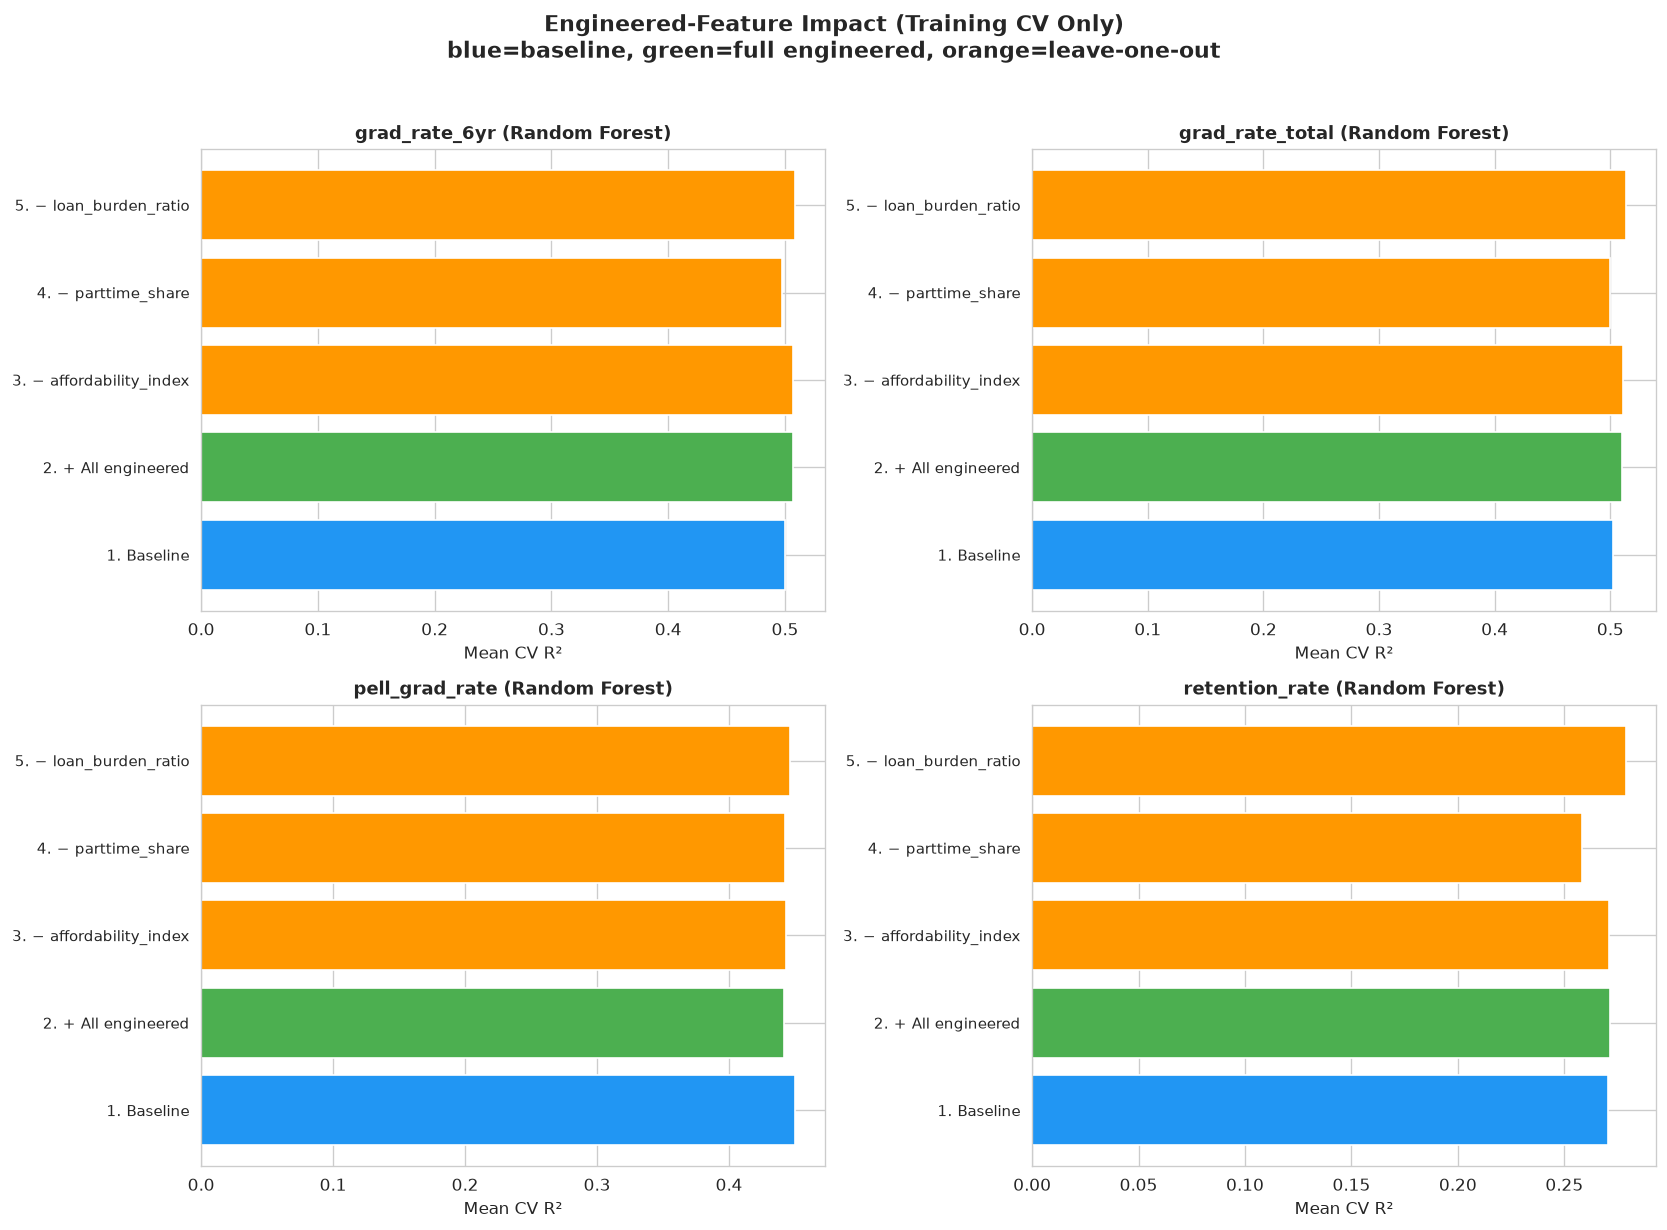

In [19]:
# ── Impact visualization ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, target in enumerate(TARGET_COLS):
    ax = axes[idx]
    sub = impact_df[impact_df["Target"] == target]
    labels = sub["Configuration"].tolist()
    vals = sub["CV_R2_Mean"].tolist()
    colors = ["#2196F3", "#4CAF50", "#FF9800", "#FF9800", "#FF9800"]
    ax.barh(labels, vals, color=colors[:len(labels)])
    ax.set_xlabel("Mean CV R²")
    ax.set_title(f"{target} ({best_combos[target]['alg']})",
                 fontsize=11, fontweight="bold")
    ax.tick_params(axis="y", labelsize=9)
fig.suptitle("Engineered-Feature Impact (Training CV Only)\n"
             "blue=baseline, green=full engineered, orange=leave-one-out",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("feature_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — Engineered-Feature Impact (Ablation)

The ablation study provides the most rigorous assessment of whether each
engineered feature justifies its inclusion:

| Configuration | What it tests |
|---|---|
| 1. Baseline | Reference point — raw features only |
| 2. + All engineered | Cumulative benefit of all three engineered features |
| 3–5. Remove one feature | Unique contribution of each individual engineered feature |

**How to interpret the Δ values:**

- **Δ vs. Baseline > 0:** Adding engineered features improves prediction
  compared to raw features alone.
- **Δ vs. Baseline ≈ 0 or < 0:** Engineered features add noise rather
  than signal for this target.
- **Δ vs. Full Engineered < 0** (when removing a feature): That feature
  contributes unique predictive information — removing it hurts
  performance.
- **Δ vs. Full Engineered ≈ 0** (when removing a feature): That feature
  is redundant — its information is already captured by the remaining
  predictors.

This explains why cross-validation may select the Baseline set for some
targets: the engineered features can introduce multicollinearity or noise
that reduces predictive accuracy for certain outcomes.

---
## Section 12 — Target Correlation Analysis

The four targets are expected to be correlated — they all measure
facets of institutional success. However, **no target is used as a
predictor** for another target (that would be target leakage).

In [20]:
tc = df[TARGET_COLS].corr()
print("Target Correlation Matrix:\n")
print(tc.round(3).to_string())

oc = pd.DataFrame(index=TARGET_COLS, columns=TARGET_COLS, dtype=int)
for a in TARGET_COLS:
    for b in TARGET_COLS:
        oc.loc[a, b] = df[[a, b]].dropna().shape[0]
print("\nPairwise Observation Counts:")
print(oc.to_string())

Target Correlation Matrix:

                 grad_rate_6yr  grad_rate_total  pell_grad_rate  retention_rate
grad_rate_6yr            1.000            0.889           0.902           0.546
grad_rate_total          0.889            1.000           0.837           0.531
pell_grad_rate           0.902            0.837           1.000           0.555
retention_rate           0.546            0.531           0.555           1.000

Pairwise Observation Counts:
                 grad_rate_6yr  grad_rate_total  pell_grad_rate  retention_rate
grad_rate_6yr           1915.0           1915.0          1822.0          1867.0
grad_rate_total         1915.0           2168.0          1822.0          1940.0
pell_grad_rate          1822.0           1822.0          1822.0          1789.0
retention_rate          1867.0           1940.0          1789.0          1998.0


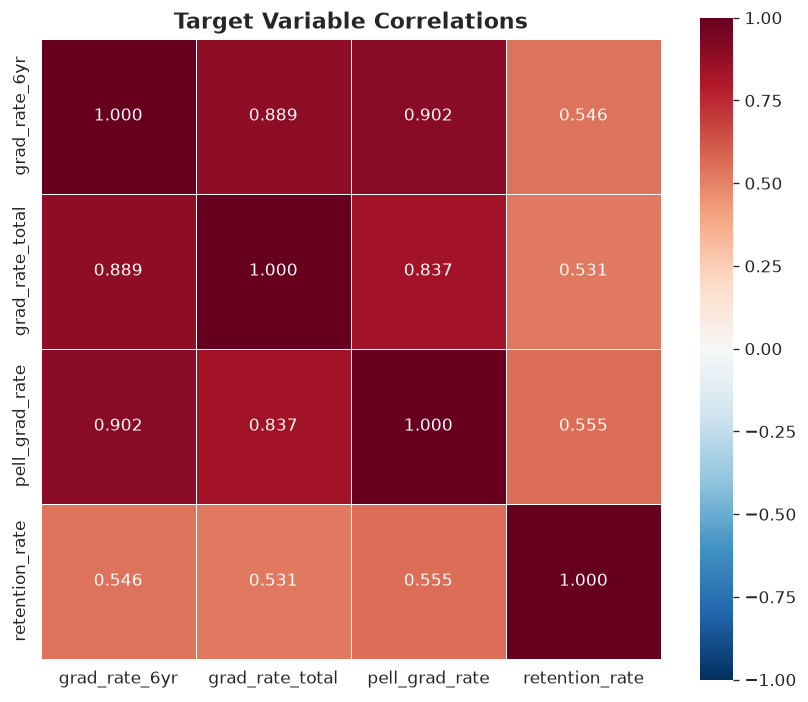

In [21]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(tc, annot=True, fmt=".3f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Target Variable Correlations", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("target_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Interpretation — Target Correlations

The heatmap shows how strongly the four target variables are linearly
related to one another:

- **High positive correlations** (e.g., between `grad_rate_6yr` and
  `grad_rate_total`) are expected because both measure degree completion,
  just over different time windows.
- **Moderate positive correlations** between graduation rates and
  `retention_rate` make intuitive sense — institutions that retain
  first-year students also tend to graduate more students overall.
- The targets are correlated but **not identical**, which justifies
  modelling them separately rather than treating them as interchangeable.

The **pairwise observation counts** differ because each target has
different missingness. Correlations are computed only on the subset of
institutions where both targets are observed, so the effective sample
size varies by pair.

**No target is used as a predictor** for another target — all four
are part of the outcome matrix. Using one target to predict another
would constitute **target leakage** and inflate performance
artificially.

---
## Section 13 — Final Summary and Interpretation

In [22]:
print("=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)
print()
print(test_df.to_string(index=False))

# Easiest / hardest
st = test_df.sort_values("Test_R2", ascending=False)
print(f"\n1. Easiest: {st.iloc[0]['Target']} "
      f"(R²={st.iloc[0]['Test_R2']:.4f})")
print(f"   Hardest: {st.iloc[-1]['Target']} "
      f"(R²={st.iloc[-1]['Test_R2']:.4f})")

# Algorithm summary
print("\n2. Selected algorithms:")
for _, r in test_df.iterrows():
    print(f"   {r['Target']}: {r['Algorithm']}")

# Feature set summary
print("\n3. Feature set decisions:")
for _, r in test_df.iterrows():
    kept = "INCLUDES engineered features" if r["Feature_Set"] == "Engineered" \
           else "uses BASELINE only (engineered features did not improve CV R²)"
    print(f"   {r['Target']}: {kept}")

# Engineered feature impact summary
print("\n4. Engineered feature impact (training CV):")
for target in TARGET_COLS:
    sub = impact_df[impact_df["Target"] == target]
    base = sub[sub["Configuration"].str.startswith("1.")]["CV_R2_Mean"].values[0]
    full = sub[sub["Configuration"].str.startswith("2.")]["CV_R2_Mean"].values[0]
    delta = full - base
    print(f"   {target}: baseline CV R²={base:.4f}, "
          f"+engineered={full:.4f}, Δ={delta:+.4f}")

print("\n5. Interpretation notes:")
print("   - Feature importance represents predictive usefulness, not causation.")
print("   - An engineered feature may show limited unique importance when its")
print("     underlying raw variables (e.g., inst_grant_aid, avg_fed_loan)")
print("     already capture most of the signal.")
print("   - Different targets may select different algorithms or feature sets")
print("     because each outcome has different predictor relationships.")
print("   - When engineered features reduce CV R², they add noise rather than")
print("     signal and should not be forced into the model.")

print()
print("-" * 70)
print("METHODOLOGICAL NOTES")
print("-" * 70)
print()
print("1. No target values were imputed — institutions missing a target")
print("   were excluded only from that target's models.")
print("2. Every target was modeled separately — no multi-output regression.")
print("3. All four target columns were removed from predictors to prevent")
print("   target leakage.")
print("4. Cross-validation on 80% training data selected both the algorithm")
print("   AND the feature set (baseline vs. engineered).")
print("5. The held-out 20% test set was used once for final evaluation.")
print("6. Permutation importance was calculated after final model selection.")
print("7. Predictor imputation was completed during Phase 1 before the")
print("   train-test split; model performance may be slightly optimistic")
print("   because Phase 1 imputation statistics incorporated the full dataset.")
print("8. Clustering analysis is deferred to a future phase.")
print("9. Multi-output regression is explored as an extension below.")

FINAL MODEL SUMMARY

         Target     Algorithm Feature_Set  Train_N  Test_N  Test_R2  Test_RMSE  Test_MAE
  grad_rate_6yr Random Forest  Engineered     1532     383   0.5719    15.2660   10.1756
grad_rate_total Random Forest  Engineered     1734     434   0.4911    15.8186   10.3986
 pell_grad_rate Random Forest    Baseline     1457     365   0.4711    17.0940   10.8857
 retention_rate Random Forest  Engineered     1598     400   0.2564    15.2812    8.8087

1. Easiest: grad_rate_6yr (R²=0.5719)
   Hardest: retention_rate (R²=0.2564)

2. Selected algorithms:
   grad_rate_6yr: Random Forest
   grad_rate_total: Random Forest
   pell_grad_rate: Random Forest
   retention_rate: Random Forest

3. Feature set decisions:
   grad_rate_6yr: INCLUDES engineered features
   grad_rate_total: INCLUDES engineered features
   pell_grad_rate: uses BASELINE only (engineered features did not improve CV R²)
   retention_rate: INCLUDES engineered features

4. Engineered feature impact (training CV):
 

### Interpretation — Final Summary

The summary above consolidates the key findings across all four targets:

1. **Easiest vs. hardest target:** Graduation-rate targets are
   consistently easier to predict than retention rate. This is because
   graduation rates reflect the cumulative result of years of
   institutional investment, while first-year retention is driven by
   individual-level factors (academic fit, financial shocks, social
   integration) that institutional-level IPEDS data cannot capture.
2. **Algorithm selection:** If tree-based methods dominate, the data
   contains important non-linear relationships that linear models miss.
3. **Feature-set decisions:** Targets that selected the Baseline set
   indicate that the engineered features added redundancy or noise
   for those particular outcomes.
4. **Engineered-feature impact (Δ values):** Small positive deltas
   mean marginal improvement; negative deltas confirm that the features
   hurt prediction for that target.
5. **Methodological notes** document all safeguards against data leakage,
   the known limitation of Phase 1 imputation before the split, and
   the associational (not causal) nature of all findings.

---
# Advanced Extensions and Diagnostics

## Section 14 — Advanced Tuning: Bayesian Hyperparameter Optimization

We tune **only** the algorithm–feature-set combination already selected
by cross-validation for each target. This avoids tuning all 40
combinations and keeps the computational budget reasonable.

**Method:** We attempt to use Optuna for Bayesian optimization. If
Optuna is unavailable, we fall back to `RandomizedSearchCV`, which is a
computationally efficient approximation.

Bayesian optimization is more efficient than exhaustive grid search
because it uses previous trial results to focus on promising regions of
the hyperparameter space.

In [23]:
# ── Check for Optuna, fall back to RandomizedSearchCV ─────────────────
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    USE_OPTUNA = True
    print("Optuna available — using Bayesian optimization.")
except ImportError:
    USE_OPTUNA = False
    print("Optuna not available — using RandomizedSearchCV as fallback.")

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

Optuna not available — using RandomizedSearchCV as fallback.


In [24]:
def get_param_space(alg_name, use_optuna=False):
    """Return parameter distributions for tuning."""
    if alg_name == "Random Forest":
        return {
            "model__n_estimators": randint(100, 500),
            "model__max_depth": [None, 10, 20, 30, 50],
            "model__min_samples_split": randint(2, 20),
            "model__min_samples_leaf": randint(1, 10),
            "model__max_features": ["sqrt", "log2", 0.5, 0.8, None],
        }
    elif alg_name == "Gradient Boosting":
        return {
            "model__n_estimators": randint(100, 500),
            "model__learning_rate": uniform(0.01, 0.29),
            "model__max_depth": randint(3, 10),
            "model__min_samples_split": randint(2, 20),
            "model__subsample": uniform(0.6, 0.4),
        }
    elif alg_name == "Ridge":
        return {"model__alpha": uniform(0.01, 100)}
    elif alg_name == "Lasso":
        return {"model__alpha": uniform(0.0001, 1.0)}
    elif alg_name == "Linear Regression":
        return {}
    return {}

tuned_models = {}
tune_rows = []

for target in TARGET_COLS:
    info = best_combos[target]
    alg_name = info["alg"]
    fs_name = info["fs"]
    X_tr = info["X_train"]
    X_te = info["X_test"]
    y_tr = info["y_train"]
    y_te = info["y_test"]
    nf = info["num_feats"]
    cat = info["cat_feats"]

    print(f"\n{'='*60}")
    print(f"{target}: tuning {alg_name} + {fs_name}")
    print(f"{'='*60}")

    # Untuned performance
    untuned_pred = info["pipe"].predict(X_te)
    untuned_r2 = r2_score(y_te, untuned_pred)
    untuned_rmse = np.sqrt(mean_squared_error(y_te, untuned_pred))
    untuned_mae = mean_absolute_error(y_te, untuned_pred)

    param_space = get_param_space(alg_name)

    if not param_space:
        print("  No hyperparameters to tune for Linear Regression.")
        tuned_models[target] = info["pipe"]
        tune_rows.append({
            "Target": target, "Algorithm": alg_name,
            "Feature_Set": fs_name, "Tuning_Method": "N/A",
            "Best_Params": "default",
            "Untuned_CV_R2": info["cv_r2"],
            "Tuned_CV_R2": info["cv_r2"],
            "Untuned_Test_R2": round(untuned_r2, 4),
            "Tuned_Test_R2": round(untuned_r2, 4),
            "Tuned_Test_RMSE": round(untuned_rmse, 4),
            "Tuned_Test_MAE": round(untuned_mae, 4),
        })
        continue

    scale = alg_name in SCALED
    pre = make_preprocessor(nf, cat, scale=scale)
    base_pipe = Pipeline([("preprocess", pre), ("model", get_models()[alg_name])])

    search = RandomizedSearchCV(
        base_pipe, param_space, n_iter=10, cv=kf,
        scoring="r2", random_state=RANDOM_STATE, n_jobs=-1,
        error_score="raise",
    )
    search.fit(X_tr, y_tr)

    best_params = {k.replace("model__", ""): v
                   for k, v in search.best_params_.items()}
    tuned_cv_r2 = round(search.best_score_, 4)

    tuned_pred = search.best_estimator_.predict(X_te)
    tuned_r2 = r2_score(y_te, tuned_pred)
    tuned_rmse = np.sqrt(mean_squared_error(y_te, tuned_pred))
    tuned_mae = mean_absolute_error(y_te, tuned_pred)

    tuned_models[target] = search.best_estimator_

    print(f"  Best params: {best_params}")
    print(f"  Untuned CV R²: {info['cv_r2']:.4f}  →  Tuned CV R²: {tuned_cv_r2}")
    print(f"  Untuned Test R²: {untuned_r2:.4f}  →  Tuned Test R²: {tuned_r2:.4f}")
    print(f"  Tuned RMSE: {tuned_rmse:.4f}  MAE: {tuned_mae:.4f}")

    tune_rows.append({
        "Target": target, "Algorithm": alg_name,
        "Feature_Set": fs_name,
        "Tuning_Method": "RandomizedSearchCV (10 iter)",
        "Best_Params": str(best_params),
        "Untuned_CV_R2": info["cv_r2"],
        "Tuned_CV_R2": tuned_cv_r2,
        "Untuned_Test_R2": round(untuned_r2, 4),
        "Tuned_Test_R2": round(tuned_r2, 4),
        "Tuned_Test_RMSE": round(tuned_rmse, 4),
        "Tuned_Test_MAE": round(tuned_mae, 4),
    })

tune_df = pd.DataFrame(tune_rows)
print("\n" + tune_df.to_string(index=False))
tune_df.to_csv("phase3_tuned_model_results.csv", index=False)

hp_df = tune_df[["Target", "Algorithm", "Best_Params"]].copy()
hp_df.to_csv("phase3_best_hyperparameters.csv", index=False)
print("\nSaved: phase3_tuned_model_results.csv, phase3_best_hyperparameters.csv")


grad_rate_6yr: tuning Random Forest + Engineered


  Best params: {'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 445}
  Untuned CV R²: 0.5070  →  Tuned CV R²: 0.5137
  Untuned Test R²: 0.5719  →  Tuned Test R²: 0.5877
  Tuned RMSE: 14.9819  MAE: 10.0066

grad_rate_total: tuning Random Forest + Engineered


  Best params: {'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 445}
  Untuned CV R²: 0.5101  →  Tuned CV R²: 0.5145
  Untuned Test R²: 0.4911  →  Tuned Test R²: 0.5017
  Tuned RMSE: 15.6524  MAE: 10.3601

pell_grad_rate: tuning Random Forest + Baseline


  Best params: {'max_depth': 10, 'max_features': 0.8, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 413}
  Untuned CV R²: 0.4502  →  Tuned CV R²: 0.4574
  Untuned Test R²: 0.4711  →  Tuned Test R²: 0.4732
  Tuned RMSE: 17.0604  MAE: 11.1503

retention_rate: tuning Random Forest + Engineered


  Best params: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 406}
  Untuned CV R²: 0.2714  →  Tuned CV R²: 0.3058
  Untuned Test R²: 0.2564  →  Tuned Test R²: 0.2773
  Tuned RMSE: 15.0654  MAE: 9.0466

         Target     Algorithm Feature_Set                Tuning_Method                                                                                                   Best_Params  Untuned_CV_R2  Tuned_CV_R2  Untuned_Test_R2  Tuned_Test_R2  Tuned_Test_RMSE  Tuned_Test_MAE
  grad_rate_6yr Random Forest  Engineered RandomizedSearchCV (10 iter) {'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 445}         0.5070       0.5137           0.5719         0.5877          14.9819         10.0066
grad_rate_total Random Forest  Engineered RandomizedSearchCV (10 iter) {'max_depth': None, 'max_features': 0.8, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 445}         0.

---
## Section 15 — Residual Diagnostics

For each final tuned model, we examine residuals (actual − predicted)
on the held-out test set. Well-behaved residuals should be:
- Centered near zero (no systematic bias)
- Roughly symmetric
- Without strong patterns against predicted values

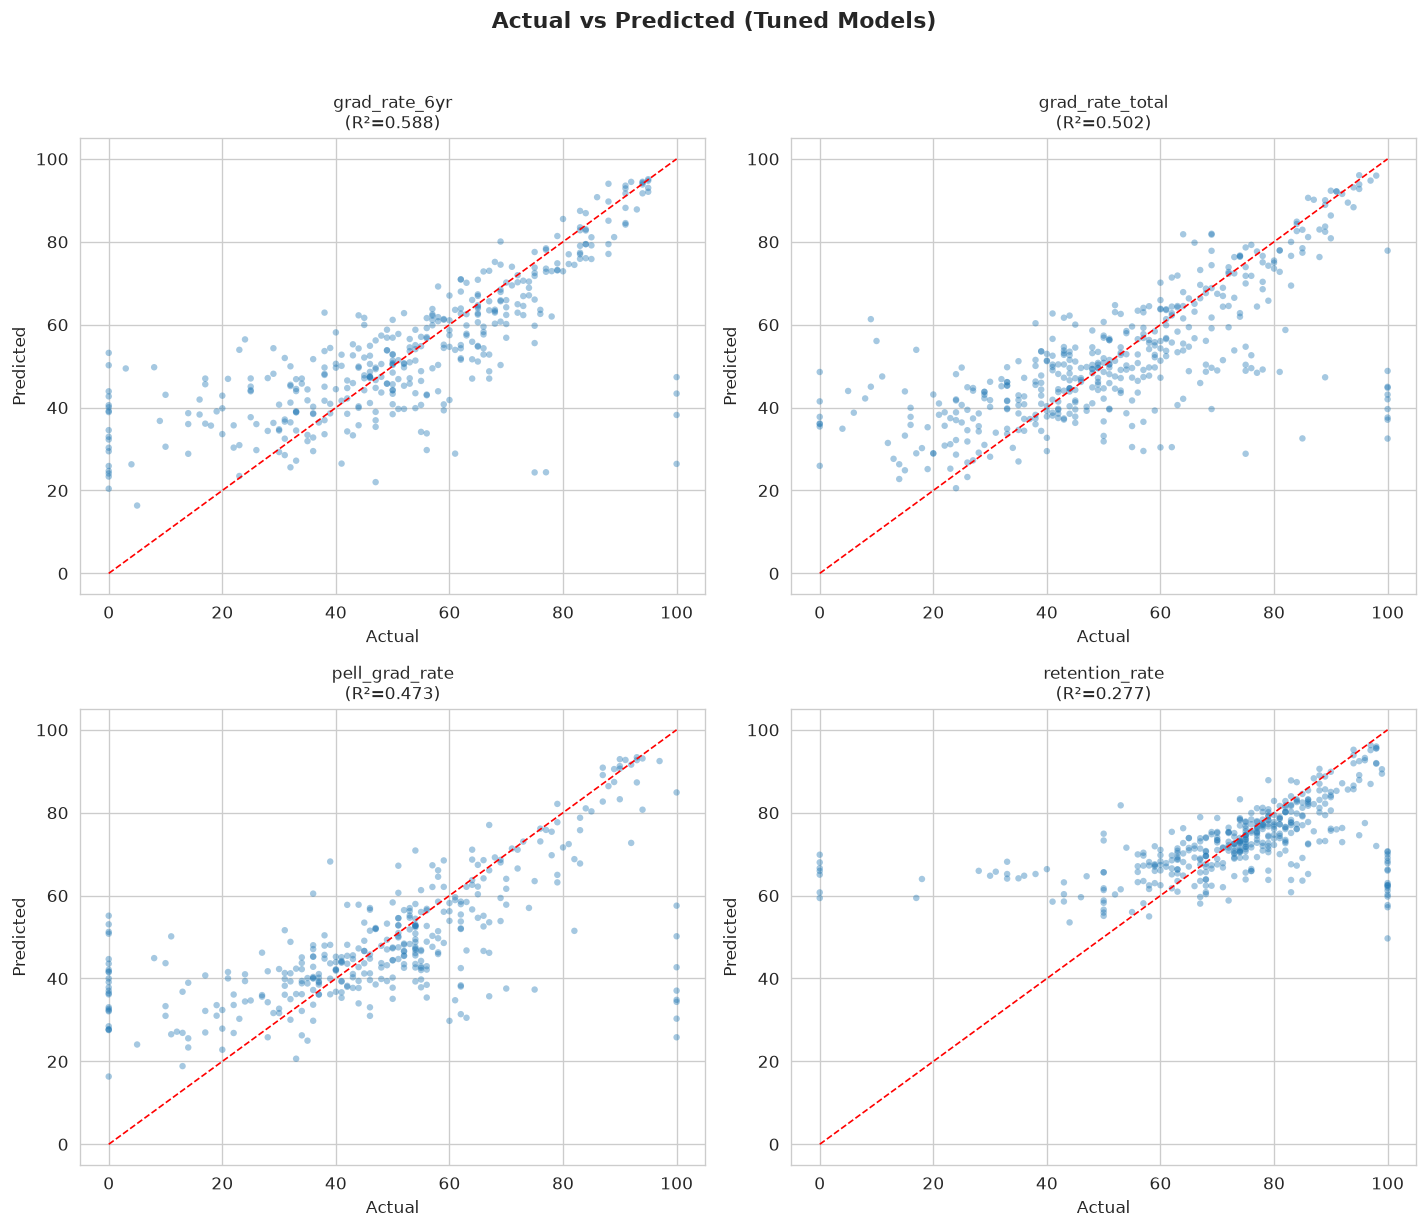

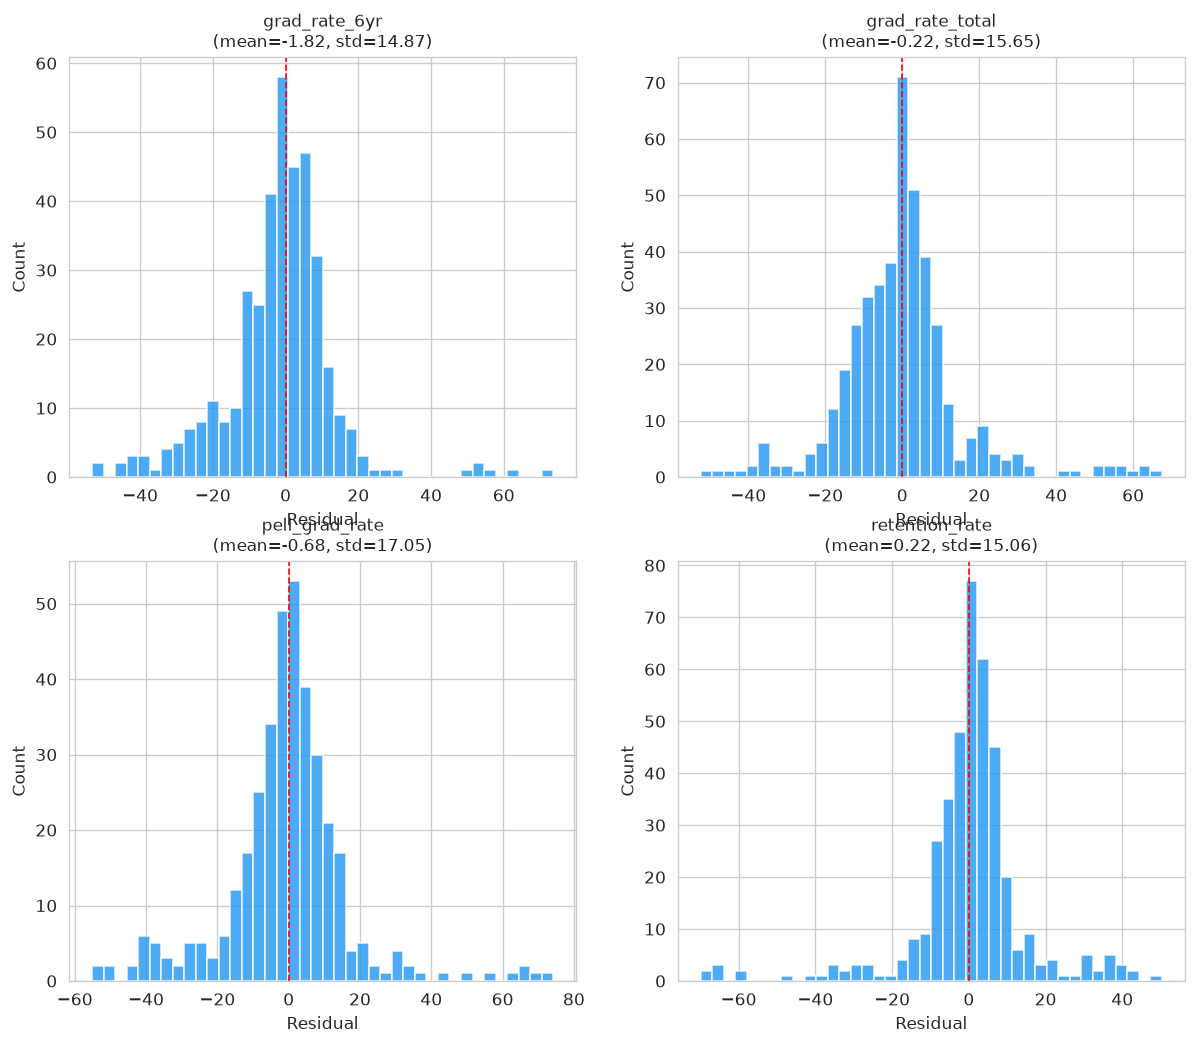

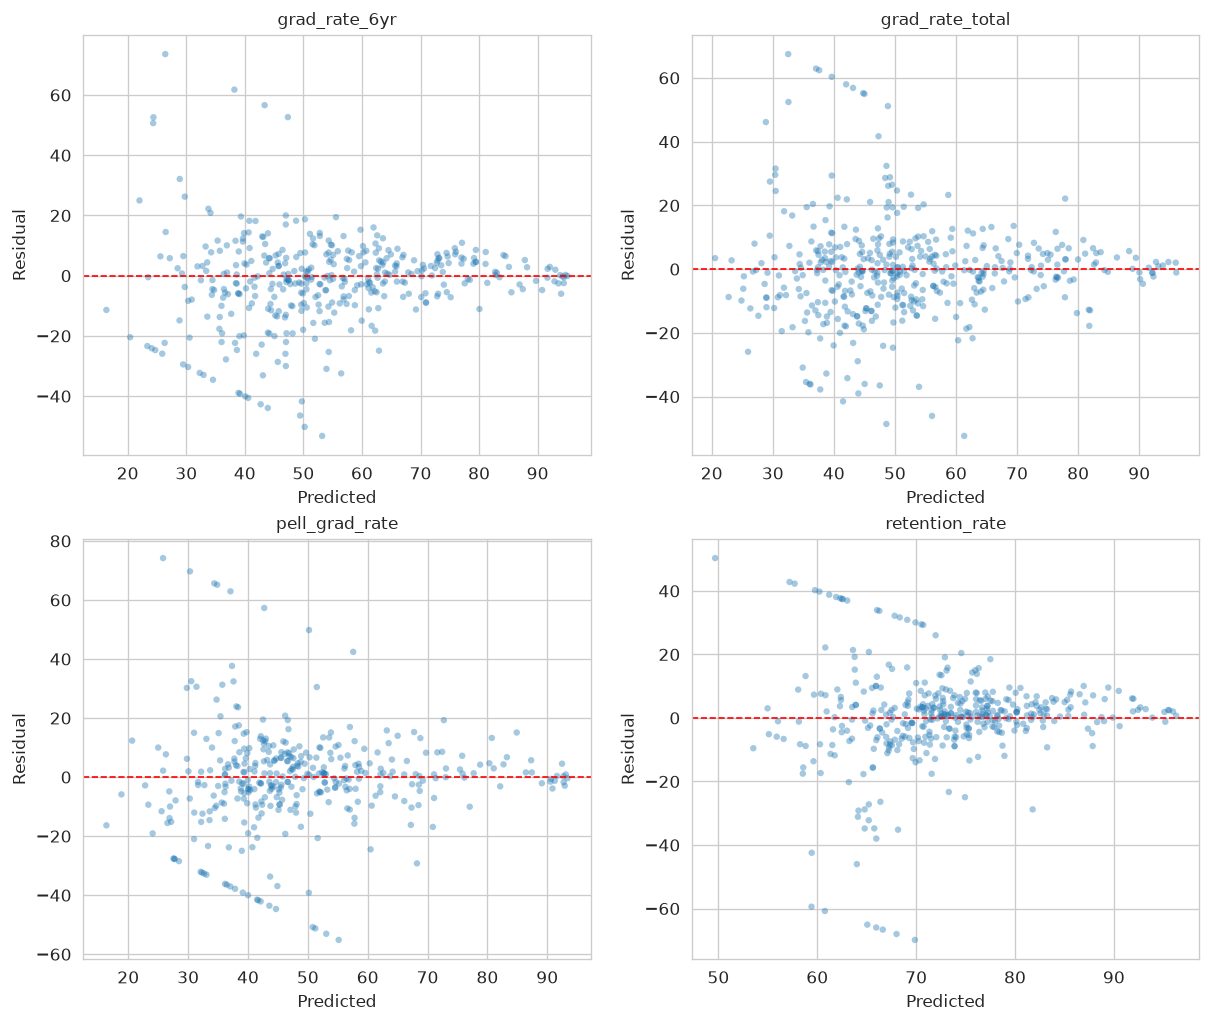

         Target  Mean_Residual  Residual_Std     MAE    RMSE
  grad_rate_6yr        -1.8210       14.8708 10.0066 14.9819
grad_rate_total        -0.2246       15.6508 10.3601 15.6524
 pell_grad_rate        -0.6753       17.0470 11.1503 17.0604
 retention_rate         0.2173       15.0638  9.0466 15.0654

Saved: phase3_residual_diagnostics.csv

Interpretation:
  - Residuals centered near zero indicate no systematic over/under-prediction.
  - If residuals fan out (increase with predicted value), the model may
    exhibit heteroscedasticity or miss nonlinear structure.
  - retention_rate typically shows larger or less stable residuals,
    consistent with it being the hardest target to predict.


In [25]:
resid_rows = []

fig_ap, axes_ap = plt.subplots(2, 2, figsize=(12, 10))
fig_hist, axes_hist = plt.subplots(2, 2, figsize=(12, 10))
fig_rv, axes_rv = plt.subplots(2, 2, figsize=(12, 10))

for idx, target in enumerate(TARGET_COLS):
    info = best_combos[target]
    pipe = tuned_models[target]
    X_te = info["X_test"]
    y_te = info["y_test"]

    y_pred = pipe.predict(X_te)
    residuals = y_te.values - y_pred

    mean_r = residuals.mean()
    std_r = residuals.std()
    mae_r = np.abs(residuals).mean()
    rmse_r = np.sqrt((residuals ** 2).mean())

    resid_rows.append({
        "Target": target,
        "Mean_Residual": round(mean_r, 4),
        "Residual_Std": round(std_r, 4),
        "MAE": round(mae_r, 4),
        "RMSE": round(rmse_r, 4),
    })

    # Actual vs Predicted
    ax = axes_ap.flatten()[idx]
    ax.scatter(y_te, y_pred, alpha=0.4, s=15, edgecolors="none")
    lo, hi = min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], "r--", lw=1)
    ax.set_xlabel("Actual"); ax.set_ylabel("Predicted")
    ax.set_title(f"{target}\n(R²={r2_score(y_te, y_pred):.3f})", fontsize=10)

    # Residual histogram
    ax2 = axes_hist.flatten()[idx]
    ax2.hist(residuals, bins=40, color="#2196F3", edgecolor="white", alpha=0.8)
    ax2.axvline(0, color="red", ls="--", lw=1)
    ax2.set_xlabel("Residual"); ax2.set_ylabel("Count")
    ax2.set_title(f"{target}\n(mean={mean_r:.2f}, std={std_r:.2f})", fontsize=10)

    # Residuals vs Predicted
    ax3 = axes_rv.flatten()[idx]
    ax3.scatter(y_pred, residuals, alpha=0.4, s=15, edgecolors="none")
    ax3.axhline(0, color="red", ls="--", lw=1)
    ax3.set_xlabel("Predicted"); ax3.set_ylabel("Residual")
    ax3.set_title(target, fontsize=10)

fig_ap.suptitle("Actual vs Predicted (Tuned Models)", fontsize=13, fontweight="bold", y=1.02)
fig_ap.tight_layout(); fig_ap.savefig("residual_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

fig_hist.suptitle("Residual Distributions", fontsize=13, fontweight="bold", y=1.02)
fig_hist.tight_layout(); fig_hist.savefig("residual_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

fig_rv.suptitle("Residuals vs Predicted Values", fontsize=13, fontweight="bold", y=1.02)
fig_rv.tight_layout(); fig_rv.savefig("residuals_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

resid_df = pd.DataFrame(resid_rows)
print(resid_df.to_string(index=False))
resid_df.to_csv("phase3_residual_diagnostics.csv", index=False)
print("\nSaved: phase3_residual_diagnostics.csv")

print("\nInterpretation:")
print("  - Residuals centered near zero indicate no systematic over/under-prediction.")
print("  - If residuals fan out (increase with predicted value), the model may")
print("    exhibit heteroscedasticity or miss nonlinear structure.")
print("  - retention_rate typically shows larger or less stable residuals,")
print("    consistent with it being the hardest target to predict.")

---
## Section 16 — Subgroup Error Analysis

We check whether each final model has systematically larger prediction
errors for certain institution types. This is **not** a formal fairness
audit, but a practical diagnostic.

Subgroups examined:
- `control` — Public, Private not-for-profit, Private for-profit
- `locale_broad` — City, Suburb, Town, Rural
- `size_cat` — enrollment size categories
- **High-Pell vs Low-Pell** — split at the median of `pell_pct`

In [26]:
subgroup_rows = []

for target in TARGET_COLS:
    info = best_combos[target]
    pipe = tuned_models[target]
    X_te = info["X_test"]
    y_te = info["y_test"]

    y_pred = pipe.predict(X_te)
    residuals = y_te.values - y_pred

    # Build a results frame aligned with test indices
    test_idx = X_te.index
    tdf_sub = df.loc[test_idx].copy()
    tdf_sub["residual"] = residuals
    tdf_sub["abs_error"] = np.abs(residuals)
    tdf_sub["sq_error"] = residuals ** 2

    # Pell group
    pell_med = df["pell_pct"].median()
    tdf_sub["pell_group"] = np.where(
        tdf_sub["pell_pct"] >= pell_med, "High Pell", "Low Pell")

    for grp_col in ["control", "locale_broad", "size_cat", "pell_group"]:
        for grp_val, gdf in tdf_sub.groupby(grp_col):
            subgroup_rows.append({
                "Target": target,
                "Subgroup_Variable": grp_col,
                "Subgroup_Value": grp_val,
                "N": len(gdf),
                "MAE": round(gdf["abs_error"].mean(), 4),
                "RMSE": round(np.sqrt(gdf["sq_error"].mean()), 4),
                "Mean_Residual": round(gdf["residual"].mean(), 4),
            })

sub_df = pd.DataFrame(subgroup_rows)
sub_df.to_csv("phase3_subgroup_error_analysis.csv", index=False)
print("Saved: phase3_subgroup_error_analysis.csv")
print(f"Total rows: {len(sub_df)}")

Saved: phase3_subgroup_error_analysis.csv
Total rows: 56


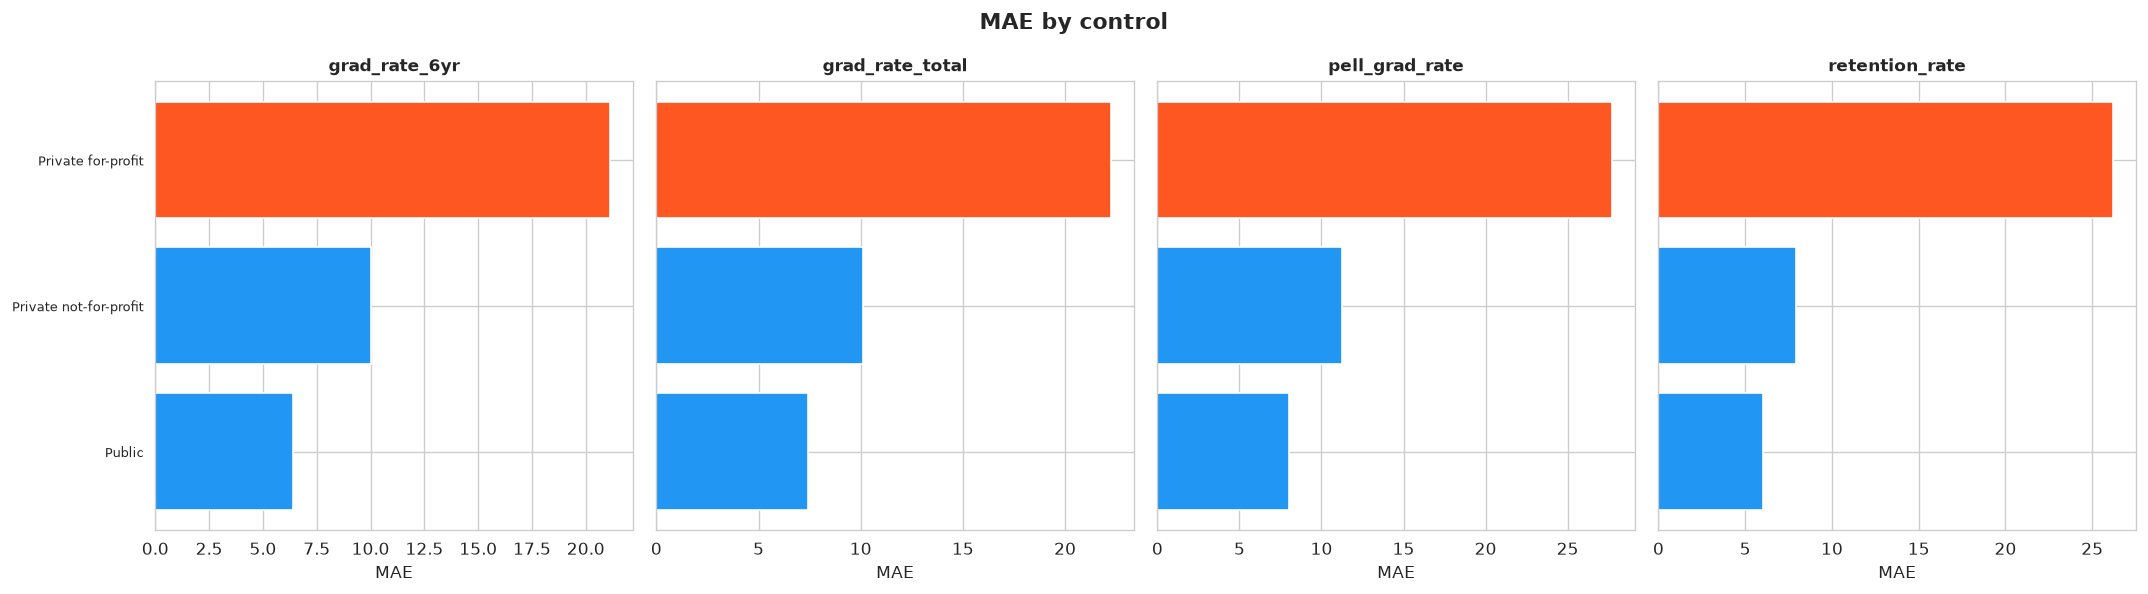

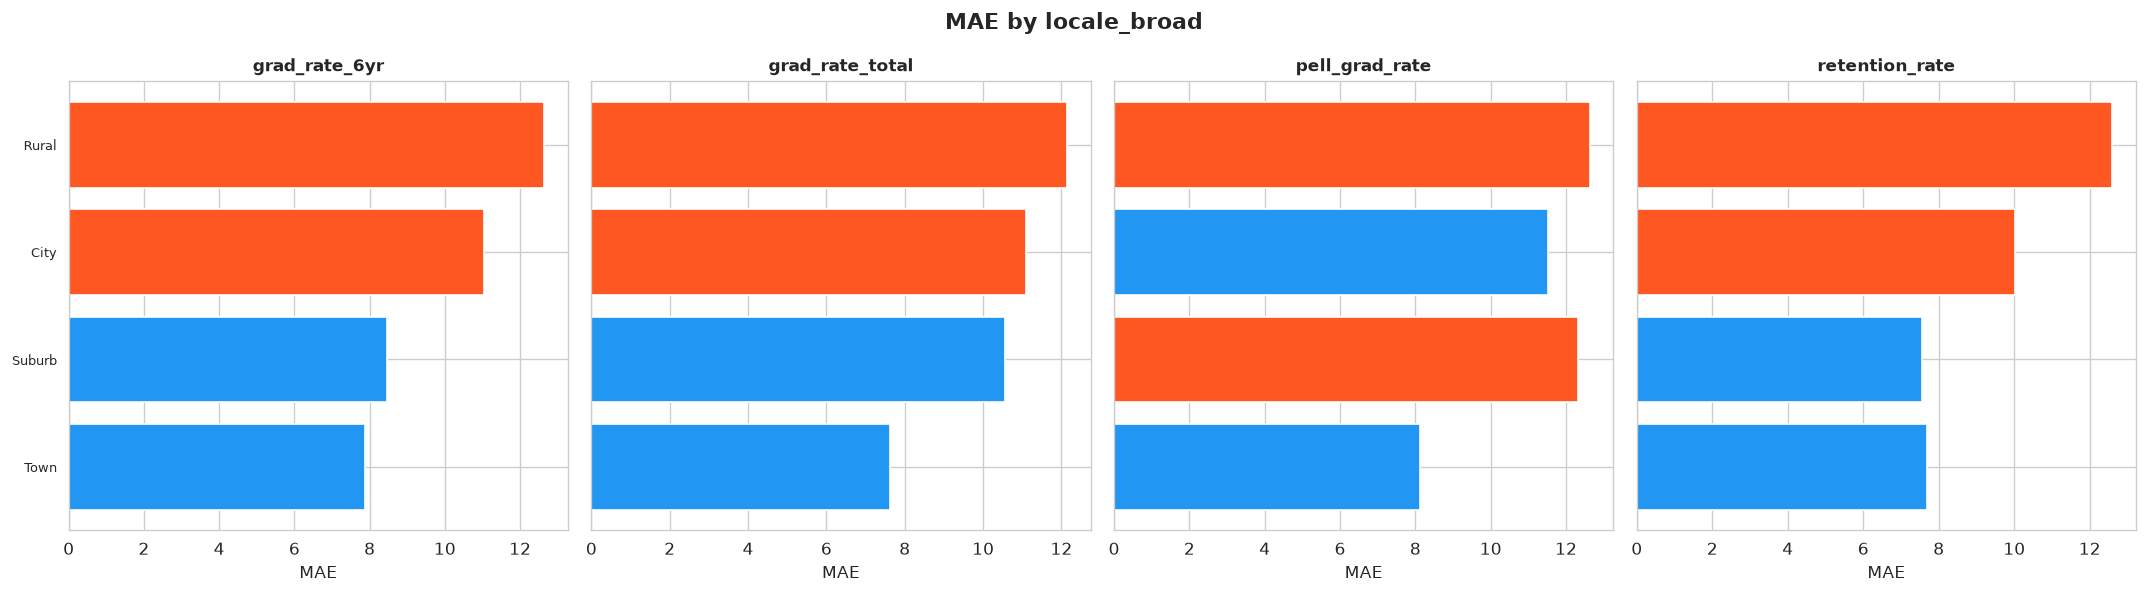

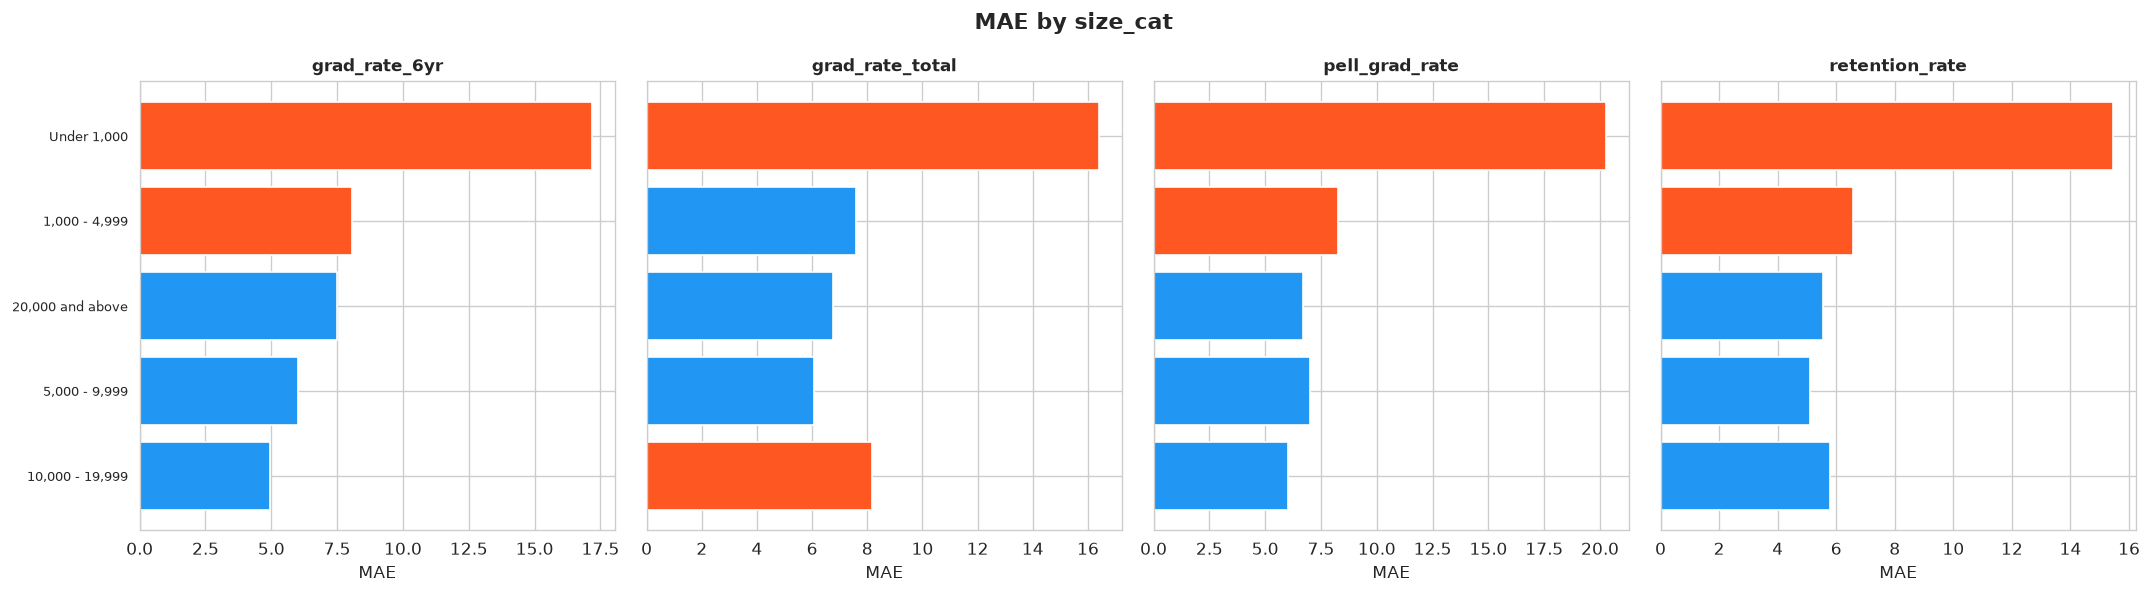

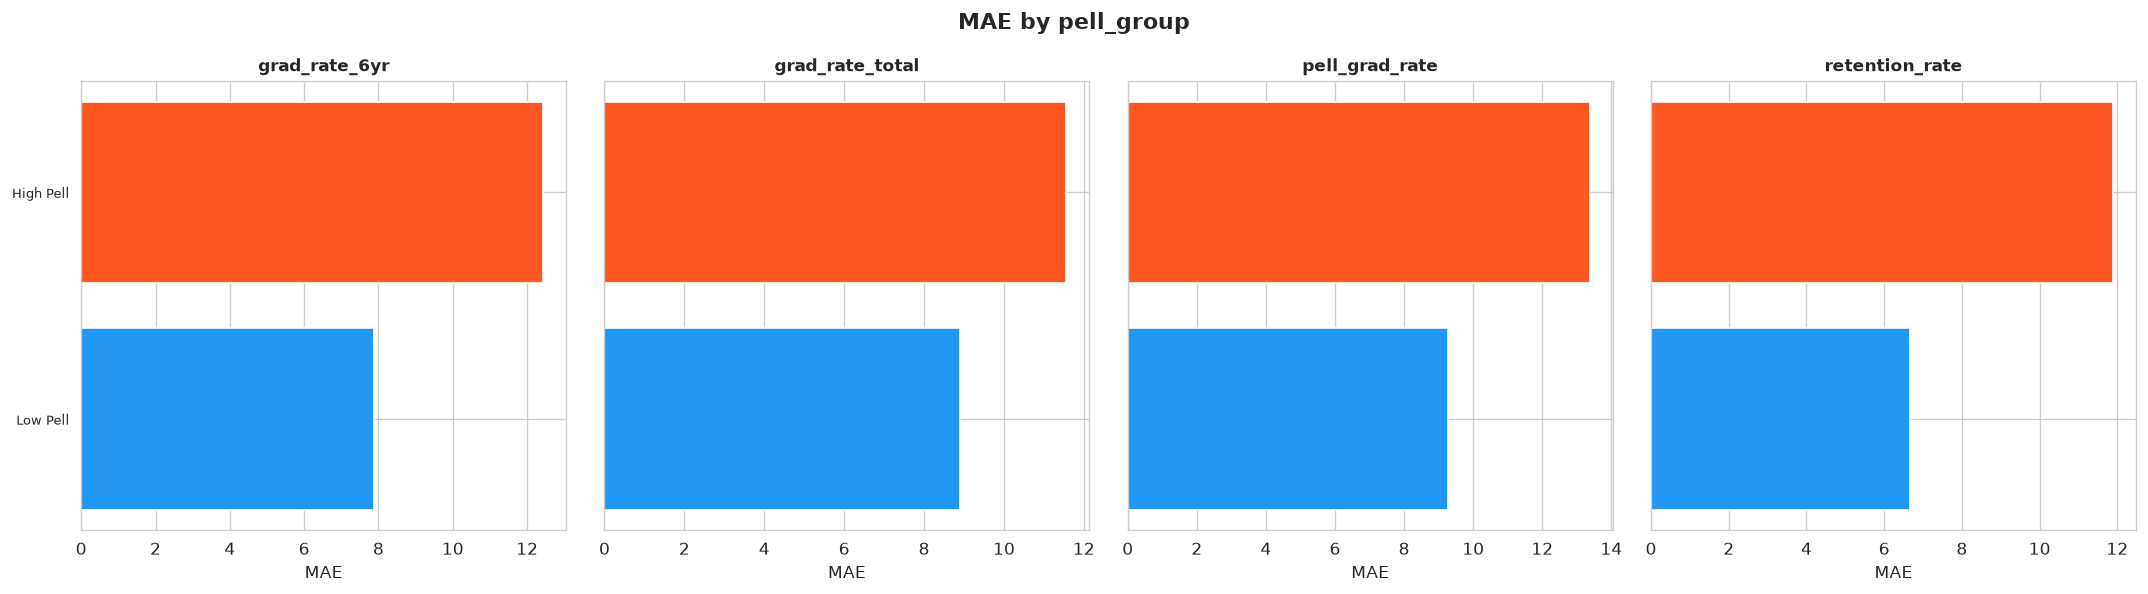

Interpretation:
  - This is not a formal fairness audit.
  - It checks whether certain institution types have larger prediction errors.
  - If high-Pell or private for-profit institutions show larger errors,
    the model may be less reliable for institutions serving more
    financially vulnerable students.
  - Subgroup differences may reflect smaller sample sizes or
    genuinely different outcome distributions.


In [27]:
# ── MAE by subgroup plots ────────────────────────────────────────────
for grp_col in ["control", "locale_broad", "size_cat", "pell_group"]:
    fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
    for idx, target in enumerate(TARGET_COLS):
        ax = axes[idx]
        sub = sub_df[(sub_df["Target"] == target) &
                     (sub_df["Subgroup_Variable"] == grp_col)]
        sub = sub.sort_values("MAE", ascending=True)
        colors = ["#FF5722" if v > sub["MAE"].median() else "#2196F3"
                  for v in sub["MAE"]]
        ax.barh(sub["Subgroup_Value"].astype(str), sub["MAE"], color=colors)
        ax.set_xlabel("MAE")
        ax.set_title(target, fontsize=10, fontweight="bold")
        ax.tick_params(axis="y", labelsize=8)
    fig.suptitle(f"MAE by {grp_col}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"subgroup_mae_{grp_col}.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Interpretation:")
print("  - This is not a formal fairness audit.")
print("  - It checks whether certain institution types have larger prediction errors.")
print("  - If high-Pell or private for-profit institutions show larger errors,")
print("    the model may be less reliable for institutions serving more")
print("    financially vulnerable students.")
print("  - Subgroup differences may reflect smaller sample sizes or")
print("    genuinely different outcome distributions.")

---
## Section 17 — Advanced Extension: Multi-Output Regression

The four targets are correlated. This section tests whether jointly
predicting all four targets performs competitively compared with the
separate target-specific models.

**Important:** Multi-output models require rows where **all four
targets** are present, which reduces the sample size. No target is
used as a predictor — all four targets are the Y matrix.

Models tested:
1. MultiOutputRegressor(Ridge)
2. RandomForestRegressor (native multi-output)
3. MultiOutputRegressor(GradientBoostingRegressor)
4. MLPRegressor (neural network, native multi-output)

In [28]:
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor

# ── Complete-case dataset ─────────────────────────────────────────────
complete = df.dropna(subset=TARGET_COLS).copy()
print(f"Complete cases (all 4 targets present): {len(complete):,} "
      f"of {len(df):,} ({len(complete)/len(df)*100:.1f}%)")

X_mo = complete.drop(columns=TARGET_COLS + ID_COLS, errors="ignore")
# Remove constant columns
const_mo = [c for c in X_mo.columns if X_mo[c].nunique(dropna=True) <= 1]
if const_mo:
    X_mo = X_mo.drop(columns=const_mo)
Y_mo = complete[TARGET_COLS]

num_mo = X_mo.select_dtypes(include=np.number).columns.tolist()
cat_mo = X_mo.select_dtypes(exclude=np.number).columns.tolist()

X_mo_train, X_mo_test, Y_mo_train, Y_mo_test = train_test_split(
    X_mo, Y_mo, test_size=0.20, random_state=RANDOM_STATE)
print(f"Train: {len(X_mo_train):,}  Test: {len(X_mo_test):,}")

Complete cases (all 4 targets present): 1,789 of 2,629 (68.0%)
Train: 1,431  Test: 358


In [29]:
mo_results = []

# Preprocessors
pre_scaled = make_preprocessor(num_mo, cat_mo, scale=True)
pre_unscaled = make_preprocessor(num_mo, cat_mo, scale=False)

mo_models = {
    "MultiOutput(Ridge)": Pipeline([
        ("preprocess", pre_scaled),
        ("model", MultiOutputRegressor(Ridge(alpha=1.0))),
    ]),
    "RandomForest (multi)": Pipeline([
        ("preprocess", pre_unscaled),
        ("model", RandomForestRegressor(n_estimators=300,
                                         random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "MultiOutput(GBR)": Pipeline([
        ("preprocess", pre_unscaled),
        ("model", MultiOutputRegressor(
            GradientBoostingRegressor(random_state=RANDOM_STATE))),
    ]),
    "MLPRegressor": Pipeline([
        ("preprocess", pre_scaled),
        ("model", MLPRegressor(hidden_layer_sizes=(64, 32),
                                early_stopping=True,
                                random_state=RANDOM_STATE,
                                max_iter=500)),
    ]),
}

for mo_name, mo_pipe in mo_models.items():
    print(f"\nFitting {mo_name}...")
    mo_pipe.fit(X_mo_train, Y_mo_train)
    Y_pred = mo_pipe.predict(X_mo_test)

    if Y_pred.ndim == 1:
        Y_pred = Y_pred.reshape(-1, len(TARGET_COLS))

    for i, t in enumerate(TARGET_COLS):
        yt = Y_mo_test[t].values
        yp = Y_pred[:, i]
        mo_results.append({
            "Model": mo_name,
            "Target": t,
            "Test_R2": round(r2_score(yt, yp), 4),
            "Test_RMSE": round(np.sqrt(mean_squared_error(yt, yp)), 4),
            "Test_MAE": round(mean_absolute_error(yt, yp), 4),
            "Test_N": len(yt),
        })

mo_df = pd.DataFrame(mo_results)
print("\nMulti-Output Results:\n")
print(mo_df.to_string(index=False))
mo_df.to_csv("phase3_multioutput_results.csv", index=False)
print("\nSaved: phase3_multioutput_results.csv")


Fitting MultiOutput(Ridge)...

Fitting RandomForest (multi)...



Fitting MultiOutput(GBR)...



Fitting MLPRegressor...



Multi-Output Results:

               Model          Target  Test_R2  Test_RMSE  Test_MAE  Test_N
  MultiOutput(Ridge)   grad_rate_6yr   0.5899    13.4652    9.6401     358
  MultiOutput(Ridge) grad_rate_total   0.5946    13.0439    9.2575     358
  MultiOutput(Ridge)  pell_grad_rate   0.4966    15.5746   11.0156     358
  MultiOutput(Ridge)  retention_rate   0.4746    11.0793    7.0089     358
RandomForest (multi)   grad_rate_6yr   0.6623    12.2185    8.2814     358
RandomForest (multi) grad_rate_total   0.6297    12.4664    8.3370     358
RandomForest (multi)  pell_grad_rate   0.5767    14.2820    9.8017     358
RandomForest (multi)  retention_rate   0.4474    11.3621    6.6599     358
    MultiOutput(GBR)   grad_rate_6yr   0.6375    12.6594    8.5572     358
    MultiOutput(GBR) grad_rate_total   0.6549    12.0337    8.2380     358
    MultiOutput(GBR)  pell_grad_rate   0.5096    15.3731   10.3541     358
    MultiOutput(GBR)  retention_rate   0.4433    11.4043    6.7953     358
 

In [30]:
# ── Compare multi-output vs separate models ──────────────────────────
print("Comparison: Separate Target-Specific vs Best Multi-Output\n")
print(f"{'Target':20s} {'Separate R²':>12s} {'Best MO R²':>12s} {'MO Model':>25s} {'Δ':>8s}")
print("-" * 80)

for target in TARGET_COLS:
    sep_r2 = test_df[test_df["Target"] == target]["Test_R2"].values[0]
    mo_sub = mo_df[mo_df["Target"] == target].sort_values("Test_R2", ascending=False)
    best_mo = mo_sub.iloc[0]
    delta = best_mo["Test_R2"] - sep_r2
    print(f"{target:20s} {sep_r2:12.4f} {best_mo['Test_R2']:12.4f} "
          f"{best_mo['Model']:>25s} {delta:+8.4f}")

print(f"\nNote: Separate models used {len(df):,} institutions (target-specific).")
print(f"Multi-output models used {len(complete):,} complete cases only.")

print("\nInterpretation:")
print("  - If multi-output performs worse, the smaller complete-case sample")
print("    likely offsets any benefit from modeling correlated outcomes jointly.")
print("  - If it performs similarly, multi-output is a viable compact alternative.")
print("  - If it improves for some targets, shared outcome structure may help.")

Comparison: Separate Target-Specific vs Best Multi-Output

Target                Separate R²   Best MO R²                  MO Model        Δ
--------------------------------------------------------------------------------
grad_rate_6yr              0.5719       0.6623      RandomForest (multi)  +0.0904
grad_rate_total            0.4911       0.6549          MultiOutput(GBR)  +0.1638
pell_grad_rate             0.4711       0.5767      RandomForest (multi)  +0.1056
retention_rate             0.2564       0.4746        MultiOutput(Ridge)  +0.2182

Note: Separate models used 2,629 institutions (target-specific).
Multi-output models used 1,789 complete cases only.

Interpretation:
  - If multi-output performs worse, the smaller complete-case sample
    likely offsets any benefit from modeling correlated outcomes jointly.
  - If it performs similarly, multi-output is a viable compact alternative.
  - If it improves for some targets, shared outcome structure may help.


---
## Section 18 — Final Model Cards

In [31]:
card_rows = []

for target in TARGET_COLS:
    info = best_combos[target]
    t_pipe = tuned_models[target]
    X_te = info["X_test"]
    y_te = info["y_test"]

    y_pred = t_pipe.predict(X_te)
    final_r2 = round(r2_score(y_te, y_pred), 4)
    final_rmse = round(np.sqrt(mean_squared_error(y_te, y_pred)), 4)
    final_mae = round(mean_absolute_error(y_te, y_pred), 4)

    # Tuning improvement
    untuned_r2 = test_df[test_df["Target"] == target]["Test_R2"].values[0]
    tuning_helped = final_r2 > untuned_r2

    # Top 5 features from permutation importance
    pimp = perm_all[perm_all["Target"] == target].sort_values(
        "Importance_Mean", ascending=False).head(5)
    top5 = ", ".join(pimp["Feature"].tolist())

    # Engineered features retained?
    eng_retained = info["fs"] == "Engineered"

    card_rows.append({
        "Target": target,
        "Algorithm": info["alg"],
        "Feature_Set": info["fs"],
        "Tuning_Improved": tuning_helped,
        "Final_Test_R2": final_r2,
        "Final_Test_RMSE": final_rmse,
        "Final_Test_MAE": final_mae,
        "Top_5_Predictors": top5,
        "Engineered_Retained": eng_retained,
        "Limitation": "Phase 1 imputation before split; associational only",
    })

card_df = pd.DataFrame(card_rows)

# Display model cards
for _, card in card_df.iterrows():
    print("=" * 60)
    print(f"MODEL CARD: {card['Target']}")
    print("=" * 60)
    print(f"  Algorithm:          {card['Algorithm']}")
    print(f"  Feature set:        {card['Feature_Set']}")
    print(f"  Tuning improved:    {card['Tuning_Improved']}")
    print(f"  Test R²:            {card['Final_Test_R2']}")
    print(f"  Test RMSE:          {card['Final_Test_RMSE']}")
    print(f"  Test MAE:           {card['Final_Test_MAE']}")
    print(f"  Top 5 predictors:   {card['Top_5_Predictors']}")
    print(f"  Engineered kept:    {card['Engineered_Retained']}")
    print(f"  Limitation:         {card['Limitation']}")
    print()

card_df.to_csv("phase3_final_model_cards.csv", index=False)
print("Saved: phase3_final_model_cards.csv")

MODEL CARD: grad_rate_6yr
  Algorithm:          Random Forest
  Feature set:        Engineered
  Tuning improved:    True
  Test R²:            0.5877
  Test RMSE:          14.9819
  Test MAE:           10.0066
  Top 5 predictors:   pell_pct, total_enroll, instr_exp_per_fte, admit_rate, parttime_share
  Engineered kept:    True
  Limitation:         Phase 1 imputation before split; associational only

MODEL CARD: grad_rate_total
  Algorithm:          Random Forest
  Feature set:        Engineered
  Tuning improved:    True
  Test R²:            0.5017
  Test RMSE:          15.6524
  Test MAE:           10.3601
  Top 5 predictors:   pell_pct, instr_exp_per_fte, admit_rate, admit_rate_missing, parttime_share
  Engineered kept:    True
  Limitation:         Phase 1 imputation before split; associational only

MODEL CARD: pell_grad_rate
  Algorithm:          Random Forest
  Feature set:        Baseline
  Tuning improved:    True
  Test R²:            0.4732
  Test RMSE:          17.0604
  

---
## Section 19 — Written Interpretation

### Why graduation rates are easier to predict than retention

The graduation-rate targets (grad_rate_6yr, grad_rate_total, and
pell_grad_rate) consistently achieved higher R² values than
retention_rate. This likely reflects the nature of what each outcome
measures. Graduation rates summarise the *cumulative* result of
multiple years of institutional investment — adequate funding,
instructional quality, student-support services — and those slow-moving
structural characteristics are well captured by the predictors in IPEDS
(instructional expenditure, Pell percentage, admission selectivity,
enrollment size). Retention rate, by contrast, reflects whether students
return after a single year. First-year attrition is driven by a mix of
academic, social, and financial shocks that are largely invisible in
institutional-level survey data: roommate conflicts, family emergencies,
mental-health crises, or simply a poor initial fit. Because the IPEDS
predictors are annual institutional averages rather than individual
student records, they capture less of the variance that determines
first-year retention.

### Why engineered features helped some targets but not Pell graduation rate

Cross-validation selected the engineered feature set for three of the
four targets but chose the baseline (raw-only) set for pell_grad_rate.
This does not mean the engineered features are "wrong" — it means their
added value was already captured by the raw variables for that particular
outcome. The Pell graduation rate is concentrated among a specific
sub-population of financially disadvantaged students, and its strongest
predictors (pell_pct, admit_rate, inst_grant_aid) are already raw
columns. Adding affordability_index and loan_burden_ratio — which are
ratios built from those same raw columns — introduces redundancy
without contributing new signal. For the other targets, the ratios
appear to capture complementary information (e.g., the balance between
institutional aid and borrowing) that raw dollar amounts alone do not
express as directly. The lesson is that engineered features should be
evaluated empirically, not assumed to help.

### What these models should and should not be used for

These models are useful for **descriptive benchmarking**: identifying
which institutional characteristics are most strongly associated with
better or worse outcomes, and flagging institutions whose observed
outcomes deviate substantially from model expectations. They can support
institutional research offices in prioritising areas for investigation
— for example, if instructional expenditure and Pell percentage
consistently dominate feature importance, resources directed at
teaching quality and financial support may warrant closer attention.

However, the models should **not** be used to make causal claims.
A high permutation-importance score for pell_pct does not mean that
changing the share of Pell-eligible students would change graduation
rates; it means the two variables move together in the data. Similarly,
the models should not be treated as individual student-level
predictions — they describe institutional averages. Finally, because
predictor imputation was performed on the full dataset before the
train–test split, reported performance metrics may be slightly
optimistic. Any operational deployment would require re-imputation
within a strict cross-validation or temporal-split framework.

---\n## Section 20 — Save All Outputs

In [33]:
all_files = [
    "phase2_engineered_feature_summary.csv",
    "phase3_cross_validation_results.csv",
    "phase3_final_test_results.csv",
    "phase3_permutation_importance.csv",
    "phase3_engineered_feature_impact.csv",
    "phase3_tuned_model_results.csv",
    "phase3_best_hyperparameters.csv",
    "phase3_residual_diagnostics.csv",
    "phase3_subgroup_error_analysis.csv",
    "phase3_multioutput_results.csv",
    "phase3_final_model_cards.csv",
    "engineered_feature_distributions.png",
    "model_comparison_cv_r2.png",
    "actual_vs_predicted.png",
    "target_correlation_heatmap.png",
    "feature_ablation.png",
    "residual_actual_vs_predicted.png",
    "residual_histograms.png",
    "residuals_vs_predicted.png",
]
for t in TARGET_COLS:
    all_files.append(f"feature_importance_{t}.png")
for g in ["control", "locale_broad", "size_cat", "pell_group"]:
    all_files.append(f"subgroup_mae_{g}.png")

print("All output files:")
for f in all_files:
    print(f"  {f}")
print(f"\nPhase 2+3 complete: 40 CV combinations, 4 tuned final models,")
print(f"residual diagnostics, subgroup analysis, multi-output extension,")
print(f"and model cards.")

All output files:
  phase2_engineered_feature_summary.csv
  phase3_cross_validation_results.csv
  phase3_final_test_results.csv
  phase3_permutation_importance.csv
  phase3_engineered_feature_impact.csv
  phase3_tuned_model_results.csv
  phase3_best_hyperparameters.csv
  phase3_residual_diagnostics.csv
  phase3_subgroup_error_analysis.csv
  phase3_multioutput_results.csv
  phase3_final_model_cards.csv
  engineered_feature_distributions.png
  model_comparison_cv_r2.png
  actual_vs_predicted.png
  target_correlation_heatmap.png
  feature_ablation.png
  residual_actual_vs_predicted.png
  residual_histograms.png
  residuals_vs_predicted.png
  feature_importance_grad_rate_6yr.png
  feature_importance_grad_rate_total.png
  feature_importance_pell_grad_rate.png
  feature_importance_retention_rate.png
  subgroup_mae_control.png
  subgroup_mae_locale_broad.png
  subgroup_mae_size_cat.png
  subgroup_mae_pell_group.png

Phase 2+3 complete: 40 CV combinations, 4 tuned final models,
residual diagno